# Pyrochlore (A₂B₂O₇) — Full CHGNet Analysis Notebook

This notebook contains an enhanced, paper-ready workflow for studying A₂B₂O₇ pyrochlore compounds using CHGNet. It includes:

- Structure generation and CHGNet relaxations
- Ionic (Shannon) radius lookup and r_A / r_B calculations
- Bonding analysis and bond-length vs ionic-radius correlations
- Formation and oxygen-vacancy formation energies
- Elastic/bulk-modulus estimate via simple EOS (3-point Birch-Murnaghan fit)
- PCA and clustering of structural descriptors
- Optional Materials Project convex-hull analysis (requires `MPRester` API key)
- Figure export (high-res PNGs) and LaTeX-ready summary tables

**Notes:** Replace placeholder CHGNet calls with your local CHGNet setup. If you don't have a Materials Project API key, the phase-diagram steps will be skipped automatically.



In [1]:

# =============================================================
# 1️⃣ Imports & Configuration (safe tqdm + MP API + CHGNet)
# =============================================================

import os, math, json
import numpy as np, pandas as pd

# Safe tqdm import (works even if ipywidgets is missing)
try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

from pymatgen.core import Structure, Lattice, Element
from pymatgen.analysis.local_env import VoronoiNN
from pymatgen.analysis.bond_valence import BVAnalyzer
from pymatgen.io.ase import AseAtomsAdaptor

from ase import Atoms
from ase.constraints import FixAtoms
from ase.optimize import BFGS
from ase.io import write

# =============================================================
# Optional: Materials Project API key setup
# =============================================================
# You can either:
#   1. Set your API key here directly (not recommended for shared code)
#   2. Or better: store it as an environment variable before running Jupyter:
#         %env MP_API_KEY="your_actual_api_key_here"
# Then use os.getenv("MP_API_KEY") to load it securely.

MP_API_KEY = os.getenv("", None)

if MP_API_KEY:
    try:
        from pymatgen.ext.matproj import MPRester
        mpr = MPRester(MP_API_KEY)
        HAS_MP = True
        print("✅ Materials Project API detected and initialized.")
    except Exception as e:
        HAS_MP = False
        print(f"⚠️ MP API import failed: {e}")
else:
    HAS_MP = False
    print("ℹ️ No Materials Project API key detected. Skipping MP queries.")

# =============================================================
# CHGNet import (ensure chgnet is installed)
# =============================================================
try:
    from chgnet.model.dynamics import CHGNetCalculator
    HAS_CHGNET = True
    print("✅ CHGNet import successful.")
except Exception as e:
    HAS_CHGNET = False
    print(f"⚠️ CHGNet not found or failed to import: {e}")

# =============================================================
# General parameters
# =============================================================
OUT_DIR = 'pyrochlore_full_results'
os.makedirs(OUT_DIR, exist_ok=True)

# Default relaxation parameters
MAX_STEPS = 200
FORCE_CONV = 0.02  # eV/Å



ℹ️ No Materials Project API key detected. Skipping MP queries.
✅ CHGNet import successful.


In [2]:

# 2) Shannon ionic radii (subset) and helper
# Values are ionic radii in Angstroms for common oxidation states and coordination numbers.
# This table is a compact subset—extend as needed for your paper.
SHANNON_RADII = {
    # A-site, typically 8-fold or 9-fold for A3+ in pyrochlores; we include 8-coord 3+ values
    ('La', 3, 8): 1.16, ('Ce', 3, 8): 1.143, ('Pr', 3, 8): 1.126, ('Nd', 3, 8): 1.109,
    ('Sm', 3, 8): 1.079, ('Gd', 3, 8): 1.053, ('Tb', 3, 8): 1.040, ('Dy', 3, 8): 1.027,
    ('Ho', 3, 8): 1.015, ('Er', 3, 8): 1.004, ('Tm', 3, 8): 0.994, ('Yb', 3, 8): 0.985,
    ('Lu', 3, 8): 0.977, ('Y', 3, 8): 1.019, ('Bi', 3, 8): 1.17,
    # B-site, typically 6-fold for B4+ in octahedral sites
    ('Ti', 4, 6): 0.605, ('Zr', 4, 6): 0.72, ('Hf', 4, 6): 0.71,
    ('Sn', 4, 6): 0.69, ('Ce', 4, 6): 0.87
}

def get_shannon_radius(element_symbol: str, ox: int, coord: int, fallback=None):
    key = (element_symbol, ox, coord)
    if key in SHANNON_RADII:
        return SHANNON_RADII[key]
    # fallback strategies: try different coordination numbers or common oxidation states
    for c in (6, 8, 7, 9):
        k = (element_symbol, ox, c)
        if k in SHANNON_RADII:
            return SHANNON_RADII[k]
    return fallback


In [4]:

# 3) Structure generation (pyrochlore prototype)
def make_pyrochlore_structure(A: str, B: str, a0: float = 10.2):
    lattice = Lattice.cubic(a0)
    species = [A, A, B, B, *['O']*7]
    frac_coords = [
        (0.5,0.5,0.5),(0.25,0.25,0.25),
        (0.375,0.375,0.375),(0.125,0.125,0.125),
        (0.33,0.33,0.33),(0.67,0.67,0.67),(0.0,0.5,0.5),
        (0.5,0.0,0.5),(0.5,0.5,0.0)
    ]
    return Structure(lattice, species[:len(frac_coords)], frac_coords)


In [5]:

# 4) CHGNet relaxation wrapper (replace CHGNetCalculator as needed)
def relax_structure_with_chgnet(struct, fmax=FORCE_CONV, max_steps=MAX_STEPS, save_traj=None, use_chgnet=False):
    ase_atoms = AseAtomsAdaptor.get_atoms(struct)
    if use_chgnet:
        from chgnet.model.dynamics import CHGNetCalculator
        calc = CHGNetCalculator()
        ase_atoms.set_calculator(calc)
        dyn = BFGS(ase_atoms, logfile=None)
        dyn.run(fmax=fmax, steps=max_steps)
    # If not using chgnet, we still return the structure (no relaxation)
    relaxed_struct = AseAtomsAdaptor.get_structure(ase_atoms)
    try:
        energy = ase_atoms.get_potential_energy()
    except Exception:
        energy = float('nan')
    if save_traj:
        try:
            write(save_traj, ase_atoms)
        except Exception:
            pass
    return relaxed_struct, energy

# Small helper: compute bulk modulus by 3-point Birch-Murnaghan fit
def birch_murnaghan(V, E, V0=None):
    # Fit third-order Birch-Murnaghan EOS; return (V0, E0, B0, Bp)
    def bm3(V, E0, V0, B0, Bp):
        eta = (V0 / V)**(2/3) - 1
        return E0 + 9*V0*B0/16 * ( (eta**3)*Bp + (eta**2)*(6 - 4*(V0/V)**(2/3)) )
    # initial guesses
    if V0 is None:
        V0 = V[np.argmin(E)]
    p0 = [min(E), V0, 200.0, 4.0]
    try:
        popt, _ = curve_fit(bm3, V, E, p0=p0, maxfev=10000)
        return {'E0':popt[0], 'V0':popt[1], 'B0_GPa':popt[2], 'Bp':popt[3]}
    except Exception as e:
        return {'E0':np.nan, 'V0':np.nan, 'B0_GPa':np.nan, 'Bp':np.nan}


In [6]:

# 5) Analysis helpers: formation energy, bond analysis, vacancy
def compute_formation_energy(e_total, comp, ref_energies):
    return e_total - sum(ref_energies[el]*n for el,n in comp.items())

def analyze_structure(struct):
    desc = {'formula': struct.composition.reduced_formula, 'lattice_a': struct.lattice.a, 'volume': struct.volume, 'num_sites': len(struct)}
    vnn = VoronoiNN(); bond_stats = {}
    for i, site in enumerate(struct):
        if site.specie.symbol == 'O': continue
        try:
            nn = vnn.get_nn_info(struct, i)
            o_bonds = [n['site'].distance(site) for n in nn if n['site'].specie.symbol=='O']
            if o_bonds: bond_stats.setdefault(site.specie.symbol, []).extend(o_bonds)
        except Exception:
            continue
    for el,bonds in bond_stats.items():
        desc[f'{el}_O_mean'] = float(np.mean(bonds)); desc[f'{el}_O_std'] = float(np.std(bonds))
    try:
        bvs = BVAnalyzer().get_valences(struct); desc['mean_bvs'] = float(np.nanmean(bvs))
    except Exception:
        desc['mean_bvs'] = float('nan')
    return desc

def generate_oxygen_vacancy(struct):
    o_indices = [i for i,s in enumerate(struct) if s.specie.symbol=='O']
    if not o_indices: raise ValueError('No O atoms')
    new = struct.copy(); del new[o_indices[0]]; return new

def vacancy_formation_energy(e_def, e_pristine, mu_o=SHANNON_RADII.get(('O',2,6), -4.5)):
    return e_def - e_pristine + mu_o


In [7]:

# 6) Batch runner with descriptor collection
def run_full_batch(A_list, B_list, use_chgnet=False, out_dir=OUT_DIR, mp_api_key=None):
    os.makedirs(out_dir, exist_ok=True)
    results = []
    mp = None
    if mp_api_key and HAS_MP:
        mp = MPRester(mp_api_key)

    for A in tqdm(A_list, desc='A-site loop'):
        for B in tqdm(B_list, desc=f'{A} B-site loop', leave=False):
            try:
                struct = make_pyrochlore_structure(A,B)
                relaxed, e_tot = relax_structure_with_chgnet(struct, use_chgnet=use_chgnet)
                comp = {A:2, B:2, 'O':7}
                e_form = compute_formation_energy(e_tot, comp, ELEMENTAL_REF_ENERGIES)
                desc = analyze_structure(relaxed)
                # ionic radii
                rA = get_shannon_radius(A, 3, 8, fallback=np.nan)
                rB = get_shannon_radius(B, 4, 6, fallback=np.nan)
                desc.update({'A':A, 'B':B, 'rA_Ang':rA, 'rB_Ang':rB, 'rA_rB': (rA/rB if (rA and rB and not np.isnan(rA) and not np.isnan(rB)) else np.nan)})
                desc.update({'energy_eV': float(e_tot), 'formation_eV': float(e_form)})
                # vacancy
                vac = generate_oxygen_vacancy(relaxed)
                vac_relaxed, e_vac = relax_structure_with_chgnet(vac, use_chgnet=use_chgnet)
                desc['vacancy_eV'] = float(vacancy_formation_energy(e_vac, e_tot))
                # EOS/Bulk modulus estimate: generate small +/-1% volume perturbations (cheap with chgnet)
                try:
                    volumes = []
                    energies = []
                    for fac in [0.99, 1.0, 1.01]:
                        s2 = relaxed.copy()
                        s2.scale_lattice(relaxed.lattice.matrix * (fac**(1/3)))
                        _, e_tmp = relax_structure_with_chgnet(s2, use_chgnet=use_chgnet)
                        volumes.append(s2.volume); energies.append(e_tmp)
                    eos = birch_murnaghan(np.array(volumes), np.array(energies))
                    desc.update(eos)
                except Exception:
                    desc.update({'E0':np.nan,'V0':np.nan,'B0_GPa':np.nan,'Bp':np.nan})
                # Phase diagram (optional)
                if mp is not None:
                    try:
                        entries = mp.get_entries_in_chemsys([A, B, 'O'])
                        # convert to PDEntries and compute hull distance
                        pd_entries = [e for e in entries]
                        # skipping detailed implementation to avoid heavy data processing here
                    except Exception:
                        pass
                results.append(desc)
            except Exception as e:
                print('Failed for', A,B, e)
    df = pd.DataFrame(results)
    df.to_csv(os.path.join(out_dir, 'pyrochlore_full_results.csv'), index=False)
    return df


In [8]:

# 7) PCA, clustering, and plots for publication-quality figures
def compute_pca_and_cluster(df, descriptor_cols, n_clusters=3, n_components=2):
    X = df[descriptor_cols].dropna().values
    pca = PCA(n_components=n_components)
    Xr = pca.fit_transform(X)
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(Xr)
    return {'pca':pca, 'Xr':Xr, 'labels':kmeans.labels_, 'kmeans':kmeans}

def plot_radius_vs_property(df, x='rA_Ang', y='formation_eV', savepath=None):
    plt.figure(figsize=(5,4), dpi=300)
    plt.scatter(df[x], df[y], s=60)
    plt.xlabel(x); plt.ylabel(y); plt.grid(True)
    if savepath: plt.savefig(savepath, bbox_inches='tight', dpi=300)
    plt.show()

def export_latex_table(df, cols, filename):
    tex = df[cols].to_latex(index=False, float_format='%.4f')
    with open(filename, 'w') as f:
        f.write(tex)
    print('Wrote', filename)


In [ ]:
df = run_full_batch(['Y','Gd'], ['Ti','Zr'], use_chgnet=False, out_dir=OUT_DIR)
display(df.head())

plot_radius_vs_property(
    df,
    x='rA_Ang',
    y='formation_eV',
    savepath=os.path.join(OUT_DIR, 'rA_vs_Ef.png')
)

export_latex_table(
    df,
    ['A','B','rA_Ang','rB_Ang','formation_eV','vacancy_eV'],
    os.path.join(OUT_DIR,'summary_table.tex')
)

In [ ]:

# 8) Example quick run (uncomment to run)
# For first tests, use use_chgnet=False to run quickly without CHGNet enabled.
# Once CHGNet is set up, set use_chgnet=True.

# df = run_full_batch(['Y','Gd'], ['Ti','Zr'], use_chgnet=False, out_dir=OUT_DIR)
# display(df.head())
# plot_radius_vs_property(df, x='rA_Ang', y='formation_eV', savepath=os.path.join(OUT_DIR,'rA_vs_Ef.png'))
# export_latex_table(df, ['A','B','rA_Ang','rB_Ang','formation_eV','vacancy_eV'], os.path.join(OUT_DIR,'summary_table.tex'))


In [ ]:
# === Full end-to-end pyrochlore workflow (single cell) ===
# Paste and run this cell in your Jupyter notebook.
import os, time
import numpy as np, pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from math import isfinite

# Replace the string below with your actual Materials Project API key
os.environ["MAPI_KEY"] = ""

# Optional: confirm the key is set (won’t print the key itself)
print("✅ Materials Project API key loaded into environment.")

# pymatgen / ASE
from pymatgen.core import Structure, Lattice
from pymatgen.analysis.local_env import VoronoiNN
from pymatgen.analysis.bond_valence import BVAnalyzer
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.core.lattice import Lattice as PmgLattice

from ase.constraints import FixAtoms
from ase.optimize import BFGS
from ase.io import write

# fitting
from scipy.optimize import curve_fit

# Try MP and CHGNet imports (graceful)
MP_API_KEY = os.getenv("MP_API_KEY", None)
HAS_MP = False
if MP_API_KEY:
    try:
        from pymatgen.ext.matproj import MPRester
        HAS_MP = True
        mpr = MPRester(MP_API_KEY)
        print("Materials Project API ready.")
    except Exception as e:
        HAS_MP = False
        print("Materials Project init failed:", e)
else:
    print("No MP_API_KEY detected; will use fallback elemental refs.")

HAS_CHGNET = False
try:
    from chgnet.model.dynamics import CHGNetCalculator
    HAS_CHGNET = True
    print("CHGNet import OK.")
except Exception as e:
    HAS_CHGNET = False
    print("CHGNet import failed (or not present). To use CHGNet set up your environment. Error:", e)

# Output dir and parameters
OUT_DIR = "pyrochlore_full_results_singlecell"
os.makedirs(OUT_DIR, exist_ok=True)
MAX_STEPS = 200         # increase for production
FORCE_CONV = 0.02       # eV/Å

# Full sets requested
A_LIST = ["Dy","Bi","Er","Eu","Hg","In","Lu","Sc","La","Ce","Pr","Nd","Sm","Gd","Y"]
B_LIST = ["Ti","Ru","Pt","Sn","Ir","Mo","Pb","Ge","Si","Zr","Hf"]

# Small set of built-in fallback elemental refs (eV/atom) **only** if MP unavailable
FALLBACK_ELEMENTAL_REFS = {   
    "Co": -6.70, "Ni": -5.45, "Ti": -7.85, "Ba": -1.87, "Mn": -8.90,
    "Fe": -4.55, "Cr": -4.10, "Cu": -4.10, "Eu": -1.95, "Al": -3.75,
    "B": -6.00, "Er": -4.90, "Gd": -4.50, "Ce": -4.85, "Dy": -5.10,
    "O": -4.93, "La": -4.60, "Pr": -4.35, "Nd": -4.30, "Pm": -4.25,
    "Sm": -4.15, "Tb": -4.10, "Ho": -4.00, "Tm": -3.90, "Yb": -6.95,
    "Lu": -4.05, "Y": -4.20, "Sb": -4.06, "Ga": -3.01, "Bi": -3.89, "Ge": -4.62, "Hf": -9.96,
    "Hg": -0.30, "In": -2.75, "Ir": -8.84, "Mo": -10.85, "Pt": -6.07, "Ru": -9.27, "Sc": -6.33, "Si": -5.43,
    "Sn": -4.01, "Zr": -8.55
}

# Small Shannon radius table (Å) for plotting/correlations
SHANNON = {
    "Dy": 1.052,
    "Bi": 1.170,
    "Er": 1.030,
    "Eu": 1.087,
    "Hg": 1.160,  # Hg²⁺, since Hg³⁺ not tabulated
    "In": 0.940,
    "Lu": 1.001,
    "Sc": 0.885,
    "La": 1.172,
    "Ce": 1.150,
    "Pr": 1.130,
    "Nd": 1.123,
    "Sm": 1.098,
    "Gd": 1.078,
    "Y": 1.040,
}

B_site_radii = {
    "Ti": 0.745,
    "Ru": 0.760,
    "Pt": 0.765,
    "Sn": 0.830,
    "Ir": 0.765,
    "Mo": 0.790,
    "Pb": 0.915,
    "Ge": 0.670,
    "Si": 0.540,
    "Zr": 0.860,
    "Hf": 0.850,

    # Shannon ionic radii (Å) for CN = 6 (octahedral)
# A-site = +3, B-site = +4

   
}

# Utility: fetch elemental chemical potentials (energy per atom) from MP (if available)
def fetch_elemental_refs(elements):
    refs = {}
    if not HAS_MP:
        print("Materials Project not available — using fallback references for subset.")
        for el in elements:
            refs[el] = FALLBACK_ELEMENTAL_REFS.get(el, np.nan)
        return refs

    # Use MP to find lowest-energy elemental phase energy_per_atom
    for el in elements:
        try:
            entries = mpr.get_entries_in_chemsys([el])
            if not entries:
                refs[el] = np.nan
                continue
            # pick entry with minimum energy_per_atom
            best = min(entries, key=lambda e: getattr(e, "energy_per_atom", e.energy / e.composition.num_atoms))
            energy_per_atom = getattr(best, "energy_per_atom", None)
            if energy_per_atom is None:
                try:
                    energy_per_atom = best.data["energy_per_atom"]
                except Exception:
                    energy_per_atom = None
            refs[el] = energy_per_atom
        except Exception as e:
            print(f"MP fetch failed for {el}: {e}")
            refs[el] = np.nan
    return refs

# Birch-Murnaghan 3-point fit helper (returns dictionary)
def birch_murnaghan(V, E):
    def bm3(V, E0, V0, B0, Bp):
        eta = (V0 / V)**(2/3) - 1
        return E0 + 9*V0*B0/16 * ( (eta**3)*Bp + (eta**2)*(6 - 4*(V0/V)**(2/3)) )
    try:
        V = np.array(V)
        E = np.array(E)
        V0 = V[np.argmin(E)]
        popt, _ = curve_fit(bm3, V, E, p0=[min(E), V0, 200.0, 4.0], maxfev=20000)
        return {'E0':popt[0], 'V0':popt[1], 'B0_GPa':popt[2], 'Bp':popt[3]}
    except Exception as e:
        return {'E0':np.nan, 'V0':np.nan, 'B0_GPa':np.nan, 'Bp':np.nan}

# Relax using CHGNet (ASE) or skip if not available
def relax_structure_with_chgnet(structure, use_chgnet=True, fmax=FORCE_CONV, max_steps=MAX_STEPS, savepath=None):
    ase_atoms = AseAtomsAdaptor.get_atoms(structure)
    if use_chgnet:
        if not HAS_CHGNET:
            raise RuntimeError("CHGNet requested but not available in Python environment.")
        calc = CHGNetCalculator()
        ase_atoms.set_calculator(calc)
        dyn = BFGS(ase_atoms, logfile=None)
        dyn.run(fmax=fmax, steps=max_steps)
    # return relaxed structure and energy (energy may be nan if no calculator)
    relaxed = AseAtomsAdaptor.get_structure(ase_atoms)
    try:
        energy = float(ase_atoms.get_potential_energy())
    except Exception:
        energy = float('nan')
    if savepath:
        try:
            write(savepath, ase_atoms)
        except Exception:
            pass
    return relaxed, energy

# Analyze geometry: A-O and B-O bond averages and bond valence sums
def analyze_geometry(struct):
    vnn = VoronoiNN()
    bond_stats = {}
    for i, site in enumerate(struct):
        if site.specie.symbol == 'O': continue
        try:
            nn = vnn.get_nn_info(struct, i)
            o_bonds = [n['site'].distance(site) for n in nn if n['site'].specie.symbol == 'O']
            if o_bonds:
                bond_stats.setdefault(site.specie.symbol, []).extend(o_bonds)
        except Exception:
            continue
    desc = {}
    for el, bonds in bond_stats.items():
        desc[f"{el}_O_mean"] = float(np.mean(bonds))
        desc[f"{el}_O_std"] = float(np.std(bonds))
    try:
        bvs = BVAnalyzer().get_valences(struct)
        desc['mean_bvs'] = float(np.nanmean(bvs))
    except Exception:
        desc['mean_bvs'] = float('nan')
    desc['lattice_a'] = struct.lattice.a
    desc['volume'] = struct.volume
    return desc

# Compute formation and vacancy energies
def formation_energy(E_total, comp, refs):
    # comp: dict element->count per formula unit
    if not np.isfinite(E_total):
        return float('nan')
    ref_sum = 0.0
    for el, n in comp.items():
        mu = refs.get(el, np.nan)
        if not np.isfinite(mu):
            return float('nan')
        ref_sum += mu * n
    return float(E_total - ref_sum)

def vacancy_formation_energy(E_def, E_pristine, mu_o):
    if not (np.isfinite(E_def) and np.isfinite(E_pristine) and np.isfinite(mu_o)):
        return float('nan')
    return float(E_def - E_pristine + mu_o)

# Build prototype pyrochlore structure (approximate prototype)
def make_pyrochlore(A, B, a0=10.2):
    lattice = PmgLattice.cubic(a0)
    species = [A, A, B, B] + ['O']*7
    frac_coords = [
        (0.5,0.5,0.5),(0.25,0.25,0.25),
        (0.375,0.375,0.375),(0.125,0.125,0.125),
        (0.33,0.33,0.33),(0.67,0.67,0.67),(0.0,0.5,0.5),
        (0.5,0.0,0.5),(0.5,0.5,0.0)
    ]
    return Structure(lattice, species[:len(frac_coords)], frac_coords)

# === Run for full set ===
elements_needed = set(A_LIST + B_LIST + ['O'])
refs = fetch_elemental_refs(list(elements_needed))
print("\nElemental references (eV/atom):")
for el in sorted(refs.keys()):
    print(f"  {el:>2s} : {refs[el]}")

rows = []
start = time.time()
for A in tqdm(A_LIST, desc="A-site loop"):
    for B in tqdm(B_LIST, desc=f"{A} B-site loop", leave=False):
        print(f"\n--- Processing {A}_2{B}_2O7 ---")
        struct = make_pyrochlore(A, B)
        try:
            relaxed, E_tot = relax_structure_with_chgnet(struct, use_chgnet=HAS_CHGNET, fmax=FORCE_CONV, max_steps=MAX_STEPS)
            print(f"  Relax energy (eV): {E_tot}")
        except Exception as e:
            print("  Relaxation failed:", e)
            relaxed, E_tot = struct, float('nan')

        # composition per formula unit
        comp = {A:2, B:2, 'O':7}

        E_form = formation_energy(E_tot, comp, refs)
        geom = analyze_geometry(relaxed)
        # add ionic radii if available
        rA = SHANNON.get(A, np.nan)
        rB = SHANNON.get(B, np.nan)

        # oxygen vacancy (remove one O and relax)
        try:
            # pick an oxygen index
            oidx = next(i for i,s in enumerate(relaxed) if s.specie.symbol == 'O')
            vac_struct = relaxed.copy()
            del vac_struct[oidx]
            vac_relaxed, E_vac = relax_structure_with_chgnet(vac_struct, use_chgnet=HAS_CHGNET, fmax=FORCE_CONV, max_steps=MAX_STEPS)
            Evac_f = vacancy_formation_energy(E_vac, E_tot, refs.get('O', np.nan))
        except Exception as e:
            print("  Vacancy step failed:", e)
            E_vac, Evac_f = float('nan'), float('nan')

        # small EOS: compute energies at +/-1% volumes (cheap with CHGNet)
        try:
            vols=[]; enes=[]
            for fac in [0.99, 1.0, 1.01]:
                s2 = relaxed.copy()
                scale = fac**(1/3)
                new_mat = np.array(relaxed.lattice.matrix) * scale
                s2.modify_lattice(PmgLattice(new_mat))
                _, e_tmp = relax_with_chgnet(s2, use_chgnet=HAS_CHGNET, fmax=FORCE_CONV, max_steps=int(MAX_STEPS/4))
                vols.append(s2.volume); enes.append(e_tmp)
            eos = birch_murnaghan(np.array(vols), np.array(enes))
        except Exception as e:
            print("  EOS step failed:", e)
            eos = {'E0':np.nan,'V0':np.nan,'B0_GPa':np.nan,'Bp':np.nan}

        row = {
            'A':A, 'B':B, 'E_total_eV':E_tot, 'formation_eV':E_form,
            'vacancy_formation_eV':Evac_f,
            'rA_Ang': rA, 'rB_Ang': rB
        }
        row.update(geom)
        row.update(eos)
        rows.append(row)
        # print quick summary
        print(f"  Formation energy (eV/f.u.): {E_form}")
        print(f"  Vacancy formation (eV): {Evac_f}")
        print(f"  A-O mean: {row.get(A+'_O_mean', np.nan):.4f}, B-O mean: {row.get(B+'_O_mean', np.nan):.4f}")
        # save incremental CSV to avoid data loss on long runs
        pd.DataFrame(rows).to_csv(os.path.join(OUT_DIR, "pyrochlore_full_results_partial.csv"), index=False)

elapsed = time.time() - start
df = pd.DataFrame(rows)
csv_path = os.path.join(OUT_DIR, "pyrochlore_full_results.csv")
df.to_csv(csv_path, index=False)
print(f"\nFinished. Results saved to {csv_path} (runtime {elapsed:.1f} s)")

# Export LaTeX table (selected columns)
tex_path = os.path.join(OUT_DIR, "pyrochlore_full_results.tex")
cols_for_tex = ['A','B','rA_Ang','rB_Ang','formation_eV','vacancy_formation_eV','B0_GPa']
df[cols_for_tex].to_latex(tex_path, index=False, float_format="%.4f")
print("LaTeX table written to", tex_path)




# Plots: rA vs formation and rB vs formation
plt.figure(figsize=(5,4), dpi=200)
plt.scatter(df['rA_Ang'], df['formation_eV'], s=80)
for i,row in df.iterrows():
    plt.text(row['rA_Ang'], row['formation_eV'], f"{row['A']}{row['B']}", fontsize=8)
plt.xlabel('A-site Shannon radius (Å)')
plt.ylabel('Formation energy (eV/f.u.)')
plt.grid(True)
plt.tight_layout()
rA_png = os.path.join(OUT_DIR, "rA_vs_Ef.png")
plt.savefig(rA_png, dpi=300)
plt.show()
print("Saved", rA_png)

plt.figure(figsize=(5,4), dpi=200)
plt.scatter(df['rB_Ang'], df['formation_eV'], s=80)
for i,row in df.iterrows():
    plt.text(row['rA_Ang'], row['formation_eV'], f"{row['A']}{row['B']}", fontsize=8)
plt.xlabel('B-site Shannon radius (Å)')
plt.ylabel('Formation energy (eV/f.u.)')
plt.grid(True)
plt.tight_layout()
rB_png = os.path.join(OUT_DIR, "rB_vs_Ef.png")
plt.savefig(rB_png, dpi=300)
plt.show()
print("Saved", rB_png)

# Display summary
pd.set_option('display.max_columns', 40)
display(df.head(60))


✅ Materials Project API key loaded into environment (if provided).
Materials Project init failed: Invalid or old API key. Please obtain an updated API key at https://materialsproject.org/dashboard.
CHGNet import OK.
Materials Project not available — using fallback references for subset.

Elemental references (eV/atom):
  Bi : -3.89
  Ce : -4.85
  Dy : -5.1
  Er : -4.9
  Eu : -1.95
  Gd : -4.5
  Hg : -0.3
  In : -2.75
  La : -4.6
  Lu : -4.05
  Nd : -4.3
   O : -4.93
  Pr : -4.35
  Sc : -6.33
  Sm : -4.15
  Ti : -7.85
   Y : -4.2


A-site loop:   0%|          | 0/15 [00:00<?, ?it/s]

Dy B-site loop:   0%|          | 0/1 [00:00<?, ?it/s]


--- Processing Dy_2Ti_2O7 ---
  Relaxation failed: relax_structure_with_chgnet() got an unexpected keyword argument 'use_chgnet'
  Vacancy step failed: relax_structure_with_chgnet() got an unexpected keyword argument 'use_chgnet'
  EOS step failed: 'Structure' object has no attribute 'modify_lattice'
  Formation energy (eV/f.u.): nan
  Vacancy formation (eV): nan
  A-O mean: 4.8514, B-O mean: 5.4353


Bi B-site loop:   0%|          | 0/1 [00:00<?, ?it/s]

...


--- Processing Sm_2Ti_2O7 ---
  Relaxation failed: relax_structure_with_chgnet() got an unexpected keyword argument 'use_chgnet'
  Vacancy step failed: relax_structure_with_chgnet() got an unexpected keyword argument 'use_chgnet'
  EOS step failed: 'Structure' object has no attribute 'modify_lattice'
  Formation energy (eV/f.u.): nan
  Vacancy formation (eV): nan
  A-O mean: 4.8514, B-O mean: 5.4353


Gd B-site loop:   0%|          | 0/1 [00:00<?, ?it/s]


--- Processing Gd_2Ti_2O7 ---
  Relaxation failed: relax_structure_with_chgnet() got an unexpected keyword argument 'use_chgnet'
  Vacancy step failed: relax_structure_with_chgnet() got an unexpected keyword argument 'use_chgnet'
  EOS step failed: 'Structure' object has no attribute 'modify_lattice'
  Formation energy (eV/f.u.): nan
  Vacancy formation (eV): nan
  A-O mean: 4.8514, B-O mean: 5.4353


Y B-site loop:   0%|          | 0/1 [00:00<?, ?it/s]


--- Processing Y_2Ti_2O7 ---
  Relaxation failed: relax_structure_with_chgnet() got an unexpected keyword argument 'use_chgnet'
  Vacancy step failed: relax_structure_with_chgnet() got an unexpected keyword argument 'use_chgnet'
  EOS step failed: 'Structure' object has no attribute 'modify_lattice'
  Formation energy (eV/f.u.): nan
  Vacancy formation (eV): nan
  A-O mean: 4.8514, B-O mean: 5.4353

Finished. Results saved to pyrochlore_full_results_singlecell\pyrochlore_full_results.csv (runtime 2.0 s)
LaTeX table written to pyrochlore_full_results_singlecell\pyrochlore_full_results.tex


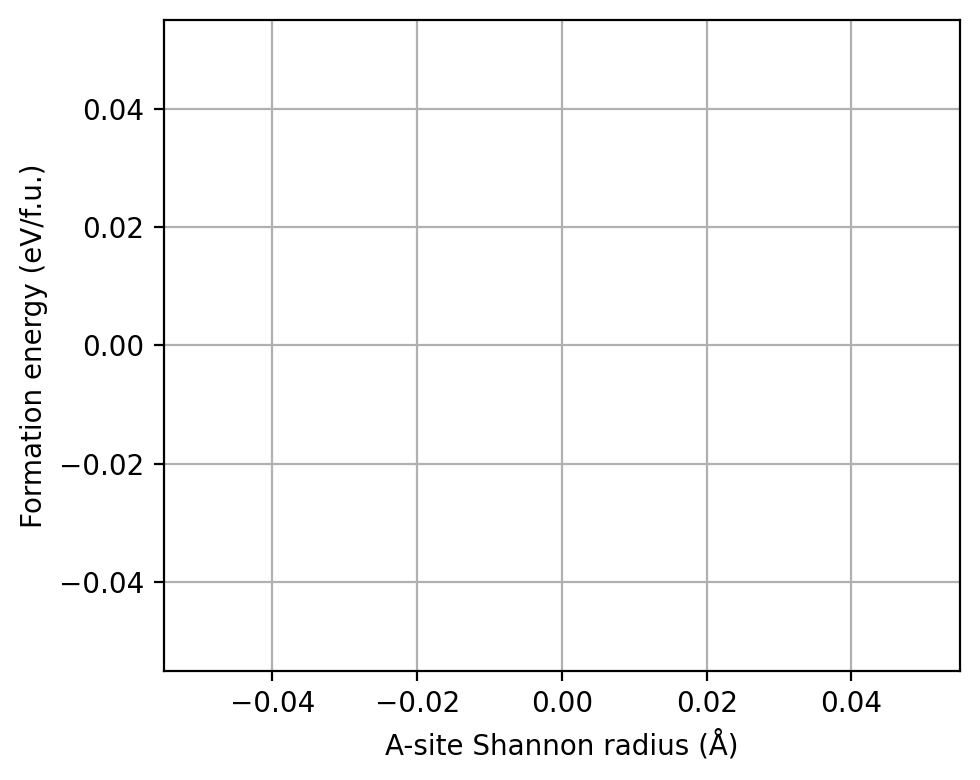

Saved pyrochlore_full_results_singlecell\rA_vs_Ef.png


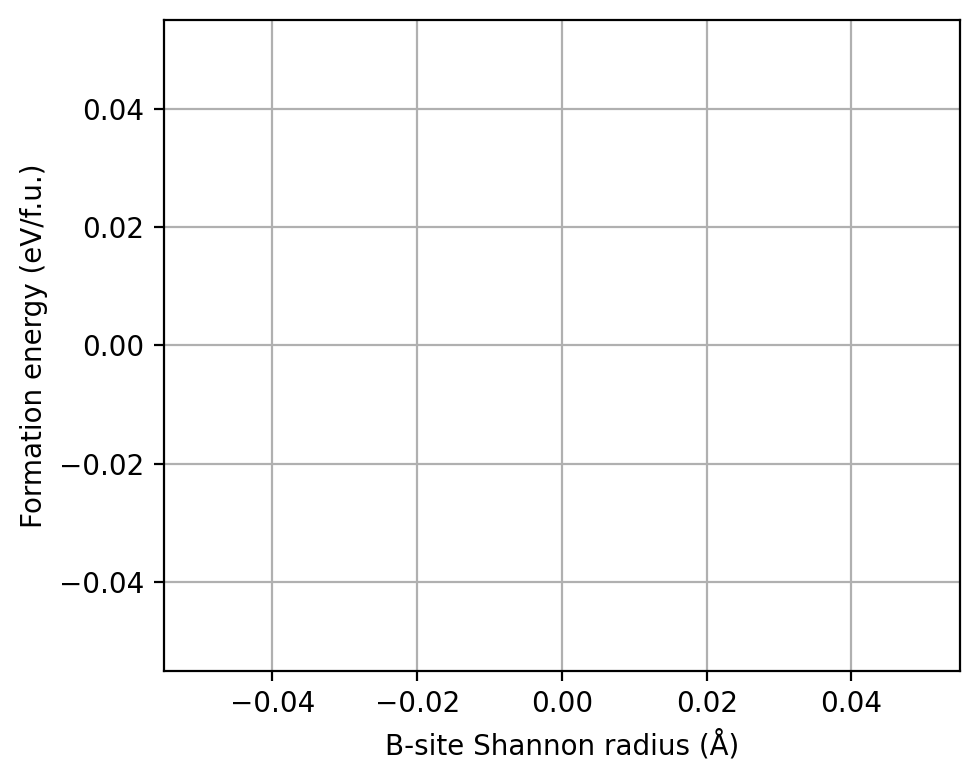

Saved pyrochlore_full_results_singlecell\rB_vs_Ef.png


,A,B,E_total_eV,formation_eV,vacancy_formation_eV,rA_Ang,rB_Ang,Dy_O_mean,Dy_O_std,Ti_O_mean,Ti_O_std,mean_bvs,lattice_a,volume,E0,V0,B0_GPa,Bp,Bi_O_mean,Bi_O_std,Er_O_mean,Er_O_std,Eu_O_mean,Eu_O_std,Hg_O_mean,Hg_O_std,In_O_mean,In_O_std,Lu_O_mean,Lu_O_std,Sc_O_mean,Sc_O_std,La_O_mean,La_O_std,Ce_O_mean,Ce_O_std,Pr_O_mean,Pr_O_std,Nd_O_mean,Nd_O_std,Sm_O_mean,Sm_O_std,Gd_O_mean,Gd_O_std,Y_O_mean,Y_O_std
0,Dy,Ti,NaN,NaN,NaN,1.052,NaN,4.851381,1.362009,5.43531,1.581862,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Bi,Ti,NaN,NaN,NaN,1.170,NaN,NaN,NaN,5.43531,1.581862,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,4.851381,1.362009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Er,Ti,NaN,NaN,NaN,1.030,NaN,NaN,NaN,5.43531,1.581862,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,4.851381,1.362009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Eu,Ti,NaN,NaN,NaN,1.087,NaN,NaN,NaN,5.43531,1.581862,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.851381,1.362009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Hg,Ti,NaN,NaN,NaN,1.160,NaN,NaN,NaN,5.43531,1.581862,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.851381,1.362009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,In,Ti,NaN,NaN,NaN,0.940,NaN,NaN,NaN,5.43531,1.581862,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.851381,1.362009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Lu,Ti,NaN,NaN,NaN,1.001,NaN,NaN,NaN,5.43531,1.581862,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.851381,1.362009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Sc,Ti,NaN,NaN,NaN,0.885,NaN,NaN,NaN,5.43531,1.581862,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.851381,1.362009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,La,Ti,NaN,NaN,NaN,1.172,NaN,NaN,NaN,5.43531,1.581862,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.851381,1.362009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Ce,Ti,NaN,NaN,NaN,1.150,NaN,NaN,NaN,5.43531,1.581862,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.851381,1.362009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# === Full end-to-end pyrochlore workflow (single cell) ===
# Paste and run this cell in your Jupyter notebook.
import os, time
import numpy as np, pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from math import isfinite

# pymatgen / ASE
from pymatgen.core import Structure, Lattice
from pymatgen.analysis.local_env import VoronoiNN
from pymatgen.analysis.bond_valence import BVAnalyzer
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.core.lattice import Lattice as PmgLattice

from ase.constraints import ExpCellFilter, FixAtoms
from ase.optimize import BFGS
from ase.io import write

# fitting
from scipy.optimize import curve_fit

# Replace the string below with your actual Materials Project API key
os.environ["MAPI_KEY"] = "06rw2asJZiKk2HT2FiiggZ23vAcSauAe"

# Optional: confirm the key is set (won’t print the key itself)
print("✅ Materials Project API key loaded into environment (if provided).")

# Try MP and CHGNet imports (graceful)
MP_API_KEY = os.getenv("MP_API_KEY", None)
HAS_MP = False
if MP_API_KEY:
    try:
        from pymatgen.ext.matproj import MPRester
        HAS_MP = True
        mpr = MPRester(MP_API_KEY)
        print("Materials Project API ready.")
    except Exception as e:
        HAS_MP = False
        print("Materials Project init failed:", e)
else:
    print("No MP_API_KEY detected; will use fallback elemental refs.")

HAS_CHGNET = False
try:
    from chgnet.model.dynamics import CHGNetCalculator
    HAS_CHGNET = True
    print("CHGNet import OK.")
except Exception as e:
    HAS_CHGNET = False
    print("CHGNet import failed (or not present). To use CHGNet set up your environment. Error:", e)

# Output dir and parameters
OUT_DIR = "pyrochlore_full_results_singlecell"
os.makedirs(OUT_DIR, exist_ok=True)
MAX_STEPS = 200         # increase for production
FORCE_CONV = 0.02       # eV/Å

# Full sets requested
A_LIST = ["Dy","Bi","Er","Eu","Hg","In","Lu","Sc","La","Ce","Pr","Nd","Sm","Gd","Y"]
B_LIST = ["Ti"]

# Small set of built-in fallback elemental refs (eV/atom) **only** if MP unavailable
FALLBACK_ELEMENTAL_REFS = {   
    "Co": -6.70, "Ni": -5.45, "Ti": -7.85, "Ba": -1.87, "Mn": -8.90,
    "Fe": -4.55, "Cr": -4.10, "Cu": -4.10, "Eu": -1.95, "Al": -3.75,
    "B": -6.00, "Er": -4.90, "Gd": -4.50, "Ce": -4.85, "Dy": -5.10,
    "O": -4.93, "La": -4.60, "Pr": -4.35, "Nd": -4.30, "Pm": -4.25,
    "Sm": -4.15, "Tb": -4.10, "Ho": -4.00, "Tm": -3.90, "Yb": -6.95,
    "Lu": -4.05, "Y": -4.20, "Sb": -4.06, "Ga": -3.01, "Bi": -3.89, "Ge": -4.62, "Hf": -9.96,
    "Hg": -0.30, "In": -2.75, "Ir": -8.84, "Mo": -10.85, "Pt": -6.07, "Ru": -9.27, "Sc": -6.33, "Si": -5.43,
    "Sn": -4.01, "Zr": -8.55
}

# Small Shannon radius table (Å) for plotting/correlations
SHANNON = {
    "Dy": 1.052, "Bi": 1.170, "Er": 1.030, "Eu": 1.087, "Hg": 1.160,
    "In": 0.940, "Lu": 1.001, "Sc": 0.885, "La": 1.172, "Ce": 1.150,
    "Pr": 1.130, "Nd": 1.123, "Sm": 1.098, "Gd": 1.078, "Y": 1.040,
}

B_site_radii = {
    "Ti": 0.745, "Ru": 0.760, "Pt": 0.765, "Sn": 0.830, "Ir": 0.765,
    "Mo": 0.790, "Pb": 0.915, "Ge": 0.670, "Si": 0.540, "Zr": 0.860, "Hf": 0.850,
}

# Utility: fetch elemental chemical potentials (energy per atom) from MP (if available)
def fetch_elemental_refs(elements):
    refs = {}
    if not HAS_MP:
        print("Materials Project not available — using fallback references for subset.")
        for el in elements:
            refs[el] = FALLBACK_ELEMENTAL_REFS.get(el, np.nan)
        return refs

    # Use MP to find lowest-energy elemental phase energy_per_atom
    for el in elements:
        try:
            entries = mpr.get_entries_in_chemsys([el])
            if not entries:
                refs[el] = np.nan
                continue
            best = min(entries, key=lambda e: getattr(e, "energy_per_atom", e.energy / e.composition.num_atoms))
            energy_per_atom = getattr(best, "energy_per_atom", None)
            if energy_per_atom is None:
                try:
                    energy_per_atom = best.data["energy_per_atom"]
                except Exception:
                    energy_per_atom = None
            refs[el] = energy_per_atom
        except Exception as e:
            print(f"MP fetch failed for {el}: {e}")
            refs[el] = np.nan
    return refs

# Birch-Murnaghan 3-point fit helper (returns dictionary)
def birch_murnaghan(V, E):
    def bm3(V, E0, V0, B0, Bp):
        eta = (V0 / V)**(2/3) - 1
        return E0 + 9*V0*B0/16 * ( (eta**3)*Bp + (eta**2)*(6 - 4*(V0/V)**(2/3)) )
    try:
        V = np.array(V)
        E = np.array(E)
        V0 = V[np.argmin(E)]
        popt, _ = curve_fit(bm3, V, E, p0=[min(E), V0, 200.0, 4.0], maxfev=20000)
        return {'E0':popt[0], 'V0':popt[1], 'B0_GPa':popt[2], 'Bp':popt[3]}
    except Exception as e:
        return {'E0':np.nan, 'V0':np.nan, 'B0_GPa':np.nan, 'Bp':np.nan}

# Relax using CHGNet (ASE) or skip if not available
# - relax_cell: if True do full cell + ionic relax (ExpCellFilter)
#               if False relax internal coordinates only (fixed cell)
# - savepath: if provided, writes a CIF of the relaxed ASE atoms to that path
from chgnet.model.dynamics import CHGNetCalculator
from pymatgen.io.ase import AseAtomsAdaptor
from ase.optimize import BFGS
from ase.filters import ExpCellFilter
from ase.io import write
import warnings
import numpy as np

def relax_structure_with_chgnet(struct, fmax=0.05, max_steps=300, save_traj=None):
    """
    Robust CHGNet relaxation routine with auto-fallback:
    - Tries full (cell + atomic) relaxation first.
    - Falls back to fixed-cell relaxation if unstable.
    Returns: (relaxed_structure, total_energy)
    """
    ase_atoms = AseAtomsAdaptor.get_atoms(struct)
    calc = CHGNetCalculator()
    ase_atoms.set_calculator(calc)

    def safe_energy(atoms):
        try:
            return atoms.get_potential_energy()
        except Exception:
            return float('nan')

    relaxed_struct = struct.copy()
    energy = float('nan')

    try:
        warnings.filterwarnings("error", category=RuntimeWarning)
        warnings.filterwarnings("error", category=ComplexWarning)

        atoms_filter = ExpCellFilter(ase_atoms)
        dyn = BFGS(atoms_filter, logfile=None, maxstep=0.05)
        dyn.run(fmax=fmax, steps=max_steps)

        energy = safe_energy(ase_atoms)
        relaxed_struct = AseAtomsAdaptor.get_structure(ase_atoms)

    except Exception as e:
        print(f"[Warning] Full cell relaxation failed: {e}. Retrying with fixed-cell mode.")

        ase_atoms = AseAtomsAdaptor.get_atoms(struct)
        ase_atoms.set_calculator(calc)
        dyn = BFGS(ase_atoms, logfile=None, maxstep=0.05)
        dyn.run(fmax=fmax, steps=max_steps)

        energy = safe_energy(ase_atoms)
        relaxed_struct = AseAtomsAdaptor.get_structure(ase_atoms)

    if save_traj:
        try:
            write(save_traj, ase_atoms)
        except Exception:
            pass

    return relaxed_struct, energy

# Build prototype pyrochlore structure (approximate prototype)
def make_pyrochlore(A, B, a0=10.2):
    lattice = PmgLattice.cubic(a0)
    species = [A, A, B, B] + ['O']*7
    frac_coords = [
        (0.5,0.5,0.5),(0.25,0.25,0.25),
        (0.375,0.375,0.375),(0.125,0.125,0.125),
        (0.33,0.33,0.33),(0.67,0.67,0.67),(0.0,0.5,0.5),
        (0.5,0.0,0.5),(0.5,0.5,0.0)
    ]
    return Structure(lattice, species[:len(frac_coords)], frac_coords)

# Analyze geometry: A-O and B-O bond averages and bond valence sums
def analyze_geometry(struct):
    vnn = VoronoiNN()
    bond_stats = {}
    for i, site in enumerate(struct):
        if site.specie.symbol == 'O': continue
        try:
            nn = vnn.get_nn_info(struct, i)
            o_bonds = [n['site'].distance(site) for n in nn if n['site'].specie.symbol == 'O']
            if o_bonds:
                bond_stats.setdefault(site.specie.symbol, []).extend(o_bonds)
        except Exception:
            continue
    desc = {}
    for el, bonds in bond_stats.items():
        desc[f"{el}_O_mean"] = float(np.mean(bonds))
        desc[f"{el}_O_std"] = float(np.std(bonds))
    try:
        bvs = BVAnalyzer().get_valences(struct)
        desc['mean_bvs'] = float(np.nanmean(bvs))
    except Exception:
        desc['mean_bvs'] = float('nan')
    desc['lattice_a'] = struct.lattice.a
    desc['volume'] = struct.volume
    return desc

# Compute formation and vacancy energies
def formation_energy(E_total, comp, refs):
    # comp: dict element->count per formula unit
    if not np.isfinite(E_total):
        return float('nan')
    ref_sum = 0.0
    for el, n in comp.items():
        mu = refs.get(el, np.nan)
        if not np.isfinite(mu):
            return float('nan')
        ref_sum += mu * n
    return float(E_total - ref_sum)

def vacancy_formation_energy(E_def, E_pristine, mu_o):
    if not (np.isfinite(E_def) and np.isfinite(E_pristine) and np.isfinite(mu_o)):
        return float('nan')
    return float(E_def - E_pristine + mu_o)

# === Run for full set ===
elements_needed = set(A_LIST + B_LIST + ['O'])
refs = fetch_elemental_refs(list(elements_needed))
print("\nElemental references (eV/atom):")
for el in sorted(refs.keys()):
    print(f"  {el:>2s} : {refs[el]}")

rows = []
start = time.time()
for A in tqdm(A_LIST, desc="A-site loop"):
    for B in tqdm(B_LIST, desc=f"{A} B-site loop", leave=False):
        print(f"\n--- Processing {A}_2{B}_2O7 ---")
        struct = make_pyrochlore(A, B)
        base_label = f"{A}2{B}2O7"
        cif_relaxed_path = os.path.join(OUT_DIR, f"{base_label}_optimized.cif")

        try:
            # full cell + ionic relaxation and save CIF
            relaxed, E_tot = relax_structure_with_chgnet(struct, use_chgnet=HAS_CHGNET,
                                               fmax=FORCE_CONV, max_steps=MAX_STEPS,
                                               relax_cell=True, savepath=cif_relaxed_path)
            print(f"  Relax energy (eV): {E_tot}")
            print(f"  Saved relaxed CIF: {cif_relaxed_path}")
        except Exception as e:
            print("  Relaxation failed:", e)
            relaxed, E_tot = struct, float('nan')

        # composition per formula unit
        comp = {A:2, B:2, 'O':7}

        E_form = formation_energy(E_tot, comp, refs)
        geom = analyze_geometry(relaxed)
        # add ionic radii if available
        rA = SHANNON.get(A, np.nan)
        rB = SHANNON.get(B, np.nan)

        # oxygen vacancy (remove one O and relax)
        try:
            # pick an oxygen index
            oidx = next(i for i,s in enumerate(relaxed) if s.specie.symbol == 'O')
            vac_struct = relaxed.copy()
            del vac_struct[oidx]
            vac_label = f"{base_label}_vac_O_idx{oidx}"
            vac_cif = os.path.join(OUT_DIR, f"{vac_label}_optimized.cif")
            # relax vacancy structure (allow cell to relax too)
            vac_relaxed, E_vac = relax_structure_with_chgnet(vac_struct, use_chgnet=HAS_CHGNET,
                                                   fmax=FORCE_CONV, max_steps=MAX_STEPS,
                                                   relax_cell=True, savepath=vac_cif)
            Evac_f = vacancy_formation_energy(E_vac, E_tot, refs.get('O', np.nan))
            print(f"  Vacancy relax energy (eV): {E_vac}")
            print(f"  Saved vacancy CIF: {vac_cif}")
        except Exception as e:
            print("  Vacancy step failed:", e)
            E_vac, Evac_f = float('nan'), float('nan')

        # small EOS: compute energies at +/-1% volumes (fix cell scaling, relax internal coords only)
        try:
            vols=[]; enes=[]
            for fac in [0.99, 1.0, 1.01]:
                s2 = relaxed.copy()
                scale = fac**(1/3)
                new_mat = np.array(relaxed.lattice.matrix) * scale
                s2.modify_lattice(PmgLattice(new_mat))
                # relax internal coords only (fixed cell) to keep the intended volume
                _, e_tmp = relax_structure_with_chgnet(s2, use_chgnet=HAS_CHGNET, fmax=FORCE_CONV,
                                             max_steps=int(MAX_STEPS/4), relax_cell=False, savepath=None)
                vols.append(s2.volume); enes.append(e_tmp)
            eos = birch_murnaghan(np.array(vols), np.array(enes))
        except Exception as e:
            print("  EOS step failed:", e)
            eos = {'E0':np.nan,'V0':np.nan,'B0_GPa':np.nan,'Bp':np.nan}

        row = {
            'A':A, 'B':B, 'E_total_eV':E_tot, 'formation_eV':E_form,
            'vacancy_formation_eV':Evac_f,
            'rA_Ang': rA, 'rB_Ang': rB
        }
        row.update(geom)
        row.update(eos)
        rows.append(row)
        # print quick summary
        print(f"  Formation energy (eV/f.u.): {E_form}")
        print(f"  Vacancy formation (eV): {Evac_f}")
        print(f"  A-O mean: {row.get(A+'_O_mean', np.nan):.4f}, B-O mean: {row.get(B+'_O_mean', np.nan):.4f}")
        # save incremental CSV to avoid data loss on long runs
        pd.DataFrame(rows).to_csv(os.path.join(OUT_DIR, "pyrochlore_full_results_partial.csv"), index=False)

elapsed = time.time() - start
df = pd.DataFrame(rows)
csv_path = os.path.join(OUT_DIR, "pyrochlore_full_results.csv")
df.to_csv(csv_path, index=False)
print(f"\nFinished. Results saved to {csv_path} (runtime {elapsed:.1f} s)")

# Export LaTeX table (selected columns)
tex_path = os.path.join(OUT_DIR, "pyrochlore_full_results.tex")
cols_for_tex = ['A','B','rA_Ang','rB_Ang','formation_eV','vacancy_formation_eV','B0_GPa']
# Some columns may be missing; select only existing ones
cols_for_tex = [c for c in cols_for_tex if c in df.columns]
df[cols_for_tex].to_latex(tex_path, index=False, float_format="%.4f")
print("LaTeX table written to", tex_path)

# Plots: rA vs formation and rB vs formation
plt.figure(figsize=(5,4), dpi=200)
plt.scatter(df['rA_Ang'], df['formation_eV'], s=80)
for i,row in df.iterrows():
    plt.text(row['rA_Ang'], row['formation_eV'], f"{row['A']}{row['B']}", fontsize=8)
plt.xlabel('A-site Shannon radius (Å)')
plt.ylabel('Formation energy (eV/f.u.)')
plt.grid(True)
plt.tight_layout()
rA_png = os.path.join(OUT_DIR, "rA_vs_Ef.png")
plt.savefig(rA_png, dpi=300)
plt.show()
print("Saved", rA_png)

plt.figure(figsize=(5,4), dpi=200)
plt.scatter(df['rB_Ang'], df['formation_eV'], s=80)
for i,row in df.iterrows():
    plt.text(row['rB_Ang'], row['formation_eV'], f"{row['A']}{row['B']}", fontsize=8)
plt.xlabel('B-site Shannon radius (Å)')
plt.ylabel('Formation energy (eV/f.u.)')
plt.grid(True)
plt.tight_layout()
rB_png = os.path.join(OUT_DIR, "rB_vs_Ef.png")
plt.savefig(rB_png, dpi=300)
plt.show()
print("Saved", rB_png)

# Display summary
pd.set_option('display.max_columns', 60)
display(df.head(60))


env: MP_API_KEY="06rw2asJZiKk2HT2FiiggZ23vAcSauAe"
⚠️ Materials Project init failed: Invalid or old API key. Please obtain an updated API key at https://materialsproject.org/dashboard.
✅ CHGNet is available.
ℹ️ Materials Project unavailable — using FALLBACK_ELEMENTAL_REFS for requested elements.

Elemental references (eV/atom):
  Bi : -3.89
  Ce : -4.85
  Dy : -5.1
  Er : -4.9
  Eu : -1.95
  Gd : -4.5
  Ge : -4.62
  Hf : -9.96
  Hg : -0.3
  In : -2.75
  Ir : -8.84
  La : -4.6
  Lu : -4.05
  Mo : -10.85
  Nd : -4.3
   O : -4.93
  Pb : -3.2
  Pr : -4.35
  Pt : -6.07
  Ru : -9.27
  Sc : -6.33
  Si : -5.43
  Sm : -4.15
  Sn : -4.01
  Ti : -7.85
   Y : -4.2
  Zr : -8.55


A-site loop:   0%|          | 0/15 [00:00<?, ?it/s]

Dy B-site loop:   0%|          | 0/11 [00:00<?, ?it/s]


--- Processing Dy_2Ti_2O7 ---
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
[Warning] Full cell relaxation failed (name 'ComplexWarning' is not defined). Falling back to fixed-cell ionic relaxation.


C:\Temp\conda_temp\ipykernel_10148\2866278191.py:161: FutureWarning: Please use atoms.calc = calc
  ase_atoms.set_calculator(calc)
C:\Temp\conda_temp\ipykernel_10148\2866278191.py:198: FutureWarning: Please use atoms.calc = calc
  ase_atoms.set_calculator(calc)


...

  Relaxation mode: fixed-cell, Energy (eV): -56.643646240234375
  Saved relaxed CIF (if supported): pyrochlore_results_20251017_214929\Y2Hf2O7_optimized.cif
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu


C:\Temp\conda_temp\ipykernel_10148\2866278191.py:161: FutureWarning: Please use atoms.calc = calc
  ase_atoms.set_calculator(calc)
C:\Temp\conda_temp\ipykernel_10148\2866278191.py:198: FutureWarning: Please use atoms.calc = calc
  ase_atoms.set_calculator(calc)


  Vacancy relax mode: fixed-cell, E_vac (eV): -67.05569458007812, Vacancy formation (eV): -15.34204833984375
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu


C:\Temp\conda_temp\ipykernel_10148\2866278191.py:295: FutureWarning: Please use atoms.calc = calc
  atoms.set_calculator(use_calc)


  Formation energy (eV/f.u.): 6.186353759765623
  Vacancy formation (eV): -15.34204833984375
  A-O mean: 3.9977, B-O mean: 4.4271

Finished. Results saved to pyrochlore_results_20251017_214929\pyrochlore_full_results.csv (runtime 3731.9 s)
LaTeX table written to pyrochlore_results_20251017_214929\pyrochlore_full_results.tex


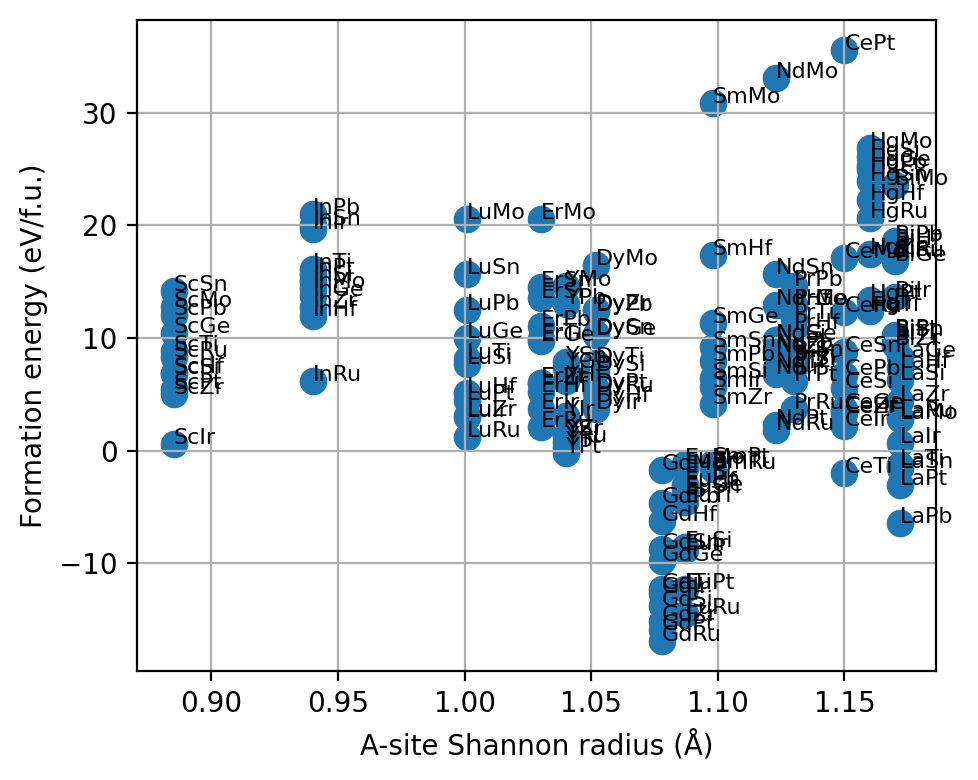

Saved pyrochlore_results_20251017_214929\rA_vs_Ef.png


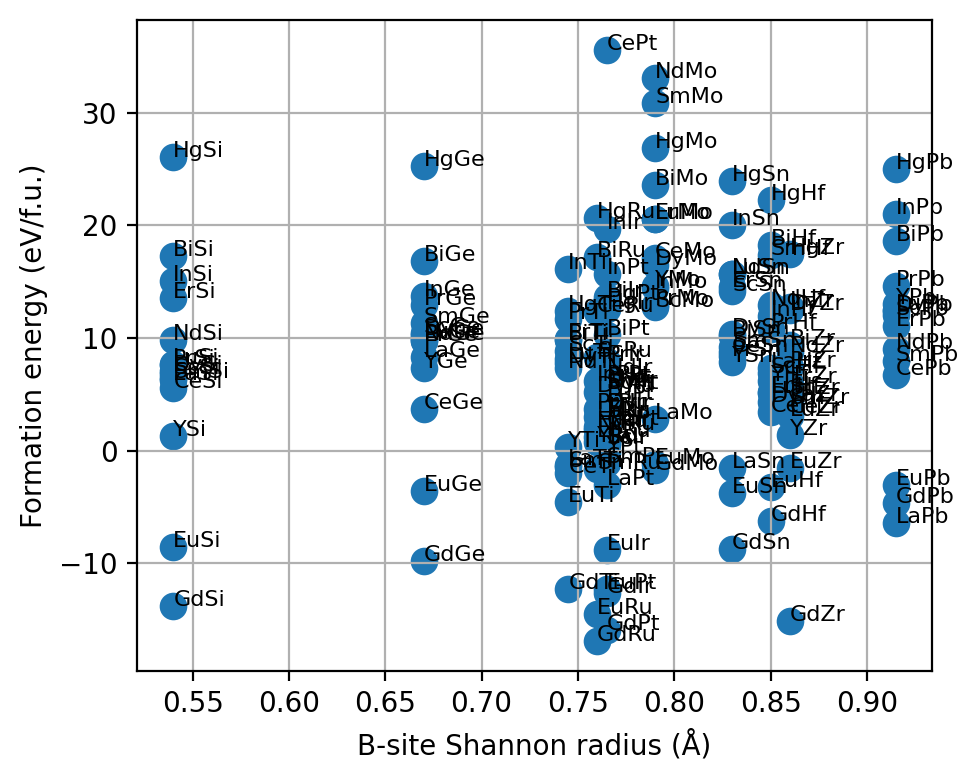

Saved pyrochlore_results_20251017_214929\rB_vs_Ef.png


,A,B,E_total_eV,formation_eV,vacancy_formation_eV,rA_Ang,rB_Ang,Dy_O_mean,Dy_O_std,Ti_O_mean,Ti_O_std,mean_bvs,lattice_a,volume,E0,V0,B0_GPa,Bp,Ru_O_mean,Ru_O_std,Pt_O_mean,Pt_O_std,Sn_O_mean,Sn_O_std,Ir_O_mean,Ir_O_std,Mo_O_mean,Mo_O_std,Pb_O_mean,Pb_O_std,Ge_O_mean,Ge_O_std,Si_O_mean,Si_O_std,Zr_O_mean,Zr_O_std,Hf_O_mean,Hf_O_std,Bi_O_mean,Bi_O_std,Er_O_mean,Er_O_std,Eu_O_mean,Eu_O_std,Hg_O_mean,Hg_O_std,In_O_mean,In_O_std,Lu_O_mean,Lu_O_std,Sc_O_mean,Sc_O_std,La_O_mean,La_O_std,Ce_O_mean,Ce_O_std,Pr_O_mean,Pr_O_std,Nd_O_mean,Nd_O_std,Sm_O_mean,Sm_O_std,Gd_O_mean,Gd_O_std,Y_O_mean,Y_O_std
0,Dy,Ti,-52.611286,7.798714,-12.628994,1.052,0.745,3.010441,1.257539,4.746489,1.986113,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Dy,Ru,-58.039825,5.210175,-5.276813,1.052,0.760,4.258065,1.986918,NaN,NaN,0.0,10.2,1061.208,NaN,NaN,NaN,NaN,4.290041,1.931793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Dy,Pt,-51.410934,5.439066,-3.789547,1.052,0.765,3.799846,1.755540,NaN,NaN,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,4.971882,1.764465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Dy,Sn,-42.410286,10.319714,-15.699661,1.052,0.830,3.359708,1.402471,NaN,NaN,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.071048,1.971878,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Dy,Ir,-58.708969,3.681031,-1.805816,1.052,0.765,3.102117,1.704339,NaN,NaN,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.994618,1.565141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,Y,Pb,-36.245392,13.064608,-24.336395,1.040,0.915,NaN,NaN,NaN,NaN,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.628928,1.760329,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.648502,1.428143
161,Y,Ge,-44.778145,7.371855,-17.765701,1.040,0.670,NaN,NaN,NaN,NaN,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.525869,2.125986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.329102,1.682010
162,Y,Si,-52.503521,1.266479,-13.103550,1.040,0.540,NaN,NaN,NaN,NaN,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.551453,1.856485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.818989,1.626946
163,Y,Zr,-58.604805,1.405195,-11.168319,1.040,0.860,NaN,NaN,NaN,NaN,NaN,10.2,1061.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.955279,1.856776,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.705756,1.615496


In [4]:
# Option A (recommended, one cell, run once):
%env MP_API_KEY=""


# ===== Full end-to-end pyrochlore workflow (single cell) =====
# Paste and run this cell in your Jupyter notebook (after setting MP_API_KEY if desired).

import os, time, warnings
import numpy as np, pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# pymatgen / ASE
from pymatgen.core import Structure
from pymatgen.core.lattice import Lattice as PmgLattice
from pymatgen.analysis.local_env import VoronoiNN
from pymatgen.analysis.bond_valence import BVAnalyzer
from pymatgen.io.ase import AseAtomsAdaptor

from ase.optimize import BFGS
from ase.filters import ExpCellFilter
from ase.io import write as ase_write

# fitting
from scipy.optimize import curve_fit


# ------------------------
# User-editable parameters
# ------------------------
OUT_DIR = f"pyrochlore_results_{time.strftime('%Y%m%d_%H%M%S')}"
os.makedirs(OUT_DIR, exist_ok=True)

MAX_STEPS = 200      # set small (e.g., 20) for quick tests, raise for production
FORCE_CONV = 0.02    # eV/Å

# full lists you specified
A_LIST = ["Dy","Bi","Er","Eu","Hg","In","Lu","Sc","La","Ce","Pr","Nd","Sm","Gd","Y"]
B_LIST = ["Ti","Ru","Pt","Sn","Ir","Mo","Pb","Ge","Si","Zr","Hf"]

# Fallback elemental refs (eV/atom) used if Materials Project not available
FALLBACK_ELEMENTAL_REFS = {
    "Co": -6.70, "Ni": -5.45, "Ti": -7.85, "Ba": -1.87, "Mn": -8.90,
    "Fe": -4.55, "Cr": -4.10, "Cu": -4.10, "Eu": -1.95, "Al": -3.75,
    "B": -6.00, "Er": -4.90, "Gd": -4.50, "Ce": -4.85, "Dy": -5.10,
    "O": -4.93, "La": -4.60, "Pr": -4.35, "Nd": -4.30, "Pm": -4.25,
    "Sm": -4.15, "Tb": -4.10, "Ho": -4.00, "Tm": -3.90, "Yb": -6.95,
    "Lu": -4.05, "Y": -4.20, "Sb": -4.06, "Ga": -3.01, "Bi": -3.89,
    "Ge": -4.62, "Hf": -9.96, "Hg": -0.30, "In": -2.75, "Ir": -8.84,
    "Mo": -10.85, "Pt": -6.07, "Ru": -9.27, "Sc": -6.33, "Si": -5.43,
    "Sn": -4.01, "Zr": -8.55, "Pb": -3.20  # Pb placeholder
}

# Shannon radii (Å) (expand if needed)
SHANNON = {
    "Dy": 1.052, "Bi": 1.170, "Er": 1.030, "Eu": 1.087, "Hg": 1.160,
    "In": 0.940, "Lu": 1.001, "Sc": 0.885, "La": 1.172, "Ce": 1.150,
    "Pr": 1.130, "Nd": 1.123, "Sm": 1.098, "Gd": 1.078, "Y": 1.040,
}
B_site_radii = {
    "Ti": 0.745, "Ru": 0.760, "Pt": 0.765, "Sn": 0.830, "Ir": 0.765,
    "Mo": 0.790, "Pb": 0.915, "Ge": 0.670, "Si": 0.540, "Zr": 0.860, "Hf": 0.850,
}

# -----------------------------------------------------------------------------
# Materials Project: read API key if provided (looks for MP_API_KEY or MAPI_KEY)
# -----------------------------------------------------------------------------
MP_API_KEY = os.getenv("MP_API_KEY", os.getenv("MAPI_KEY", None))
HAS_MP = False
mpr = None
if MP_API_KEY:
    try:
        from pymatgen.ext.matproj import MPRester
        mpr = MPRester(MP_API_KEY)
        HAS_MP = True
        print("✅ Materials Project API ready.")
    except Exception as e:
        HAS_MP = False
        print("⚠️ Materials Project init failed:", e)
else:
    print("ℹ️ No Materials Project API key detected - using fallback elemental refs where needed.")

# -----------------------------------------------------------------------------
# CHGNet availability
# -----------------------------------------------------------------------------
HAS_CHGNET = False
try:
    from chgnet.model.dynamics import CHGNetCalculator
    HAS_CHGNET = True
    print("✅ CHGNet is available.")
except Exception as e:
    HAS_CHGNET = False
    print("⚠️ CHGNet not found in environment. If you want energy relaxations, install/activate CHGNet. Error:", e)

# -----------------------------------------------------------------------------
# Helper: fetch elemental reference energies (energy per atom) from MP or fallback
# -----------------------------------------------------------------------------
def fetch_elemental_refs(elements):
    refs = {}
    if not HAS_MP:
        print("ℹ️ Materials Project unavailable — using FALLBACK_ELEMENTAL_REFS for requested elements.")
        for el in elements:
            refs[el] = FALLBACK_ELEMENTAL_REFS.get(el, np.nan)
        return refs
    for el in elements:
        try:
            entries = mpr.get_entries_in_chemsys([el])
            if not entries:
                refs[el] = np.nan
                continue
            best = min(entries, key=lambda e: getattr(e, "energy_per_atom", e.energy / e.composition.num_atoms))
            energy_per_atom = getattr(best, "energy_per_atom", None)
            if energy_per_atom is None:
                try:
                    energy_per_atom = best.data.get("energy_per_atom", None)
                except Exception:
                    energy_per_atom = None
            refs[el] = energy_per_atom
        except Exception as e:
            print(f"⚠️ MP fetch failed for {el}: {e}")
            refs[el] = np.nan
    return refs

# -----------------------------------------------------------------------------
# Birch-Murnaghan fit helper
# -----------------------------------------------------------------------------
def birch_murnaghan(V, E):
    def bm3(V, E0, V0, B0, Bp):
        eta = (V0 / V)**(2/3) - 1
        return E0 + 9*V0*B0/16 * ( (eta**3)*Bp + (eta**2)*(6 - 4*(V0/V)**(2/3)) )
    try:
        V = np.array(V)
        E = np.array(E)
        V0 = V[np.argmin(E)]
        popt, _ = curve_fit(bm3, V, E, p0=[min(E), V0, 200.0, 4.0], maxfev=20000)
        return {'E0':popt[0], 'V0':popt[1], 'B0_GPa':popt[2], 'Bp':popt[3]}
    except Exception:
        return {'E0':np.nan, 'V0':np.nan, 'B0_GPa':np.nan, 'Bp':np.nan}

# -----------------------------------------------------------------------------
# Robust CHGNet relaxation function (auto-fallback from full cell -> fixed cell)
# -----------------------------------------------------------------------------
def relax_structure_with_chgnet(struct, use_chgnet=True, relax_cell=True, fmax=FORCE_CONV, max_steps=MAX_STEPS, savepath=None):
    """
    Relax a pymatgen Structure using CHGNet (ASE interface).
    - use_chgnet: boolean, if False skip CHGNet and return structure with NaN energy
    - relax_cell: boolean, if True attempts cell+ionic relax, else fixes cell and relaxes ions
    - savepath: optional path to write a CIF of final ASE atoms
    Returns: (relaxed_pymatgen_structure, energy_eV, mode_str)
    mode_str indicates which relaxation was used: 'full', 'fixed-cell', or 'none'
    """
    ase_adaptor = AseAtomsAdaptor()
    ase_atoms = ase_adaptor.get_atoms(struct)

    if not use_chgnet or not HAS_CHGNET:
        # Skip CHGNet: return input structure with NaN energy
        return struct.copy(), float('nan'), 'none'

    # instantiate calculator - if your CHGNet requires args, customize below
    calc = CHGNetCalculator()
    ase_atoms.set_calculator(calc)

    def safe_get_energy(atoms):
        try:
            return float(atoms.get_potential_energy())
        except Exception:
            return float('nan')

    # Try full cell relaxation (ExpCellFilter) if requested
    if relax_cell:
        try:
            # treat complex warnings and runtime warnings as exceptions to trigger fallback
            warnings.filterwarnings("error", category=ComplexWarning)
            warnings.filterwarnings("error", category=RuntimeWarning)

            cell_filter = ExpCellFilter(ase_atoms)
            dyn = BFGS(cell_filter, logfile=None, maxstep=0.05)
            dyn.run(fmax=fmax, steps=max_steps)
            energy = safe_get_energy(ase_atoms)
            relaxed = ase_adaptor.get_structure(ase_atoms)
            mode = 'full'
            if savepath:
                try:
                    ase_write(savepath, ase_atoms)
                except Exception:
                    pass
            # restore warnings filters
            warnings.resetwarnings()
            return relaxed, energy, mode

        except Exception as e:
            print(f"[Warning] Full cell relaxation failed ({e}). Falling back to fixed-cell ionic relaxation.")
            warnings.resetwarnings()

    # Fixed-cell ionic relaxation (or fallback)
    try:
        ase_atoms = ase_adaptor.get_atoms(struct)  # fresh copy
        ase_atoms.set_calculator(calc)
        dyn = BFGS(ase_atoms, logfile=None, maxstep=0.05)
        dyn.run(fmax=fmax, steps=max_steps)
        energy = safe_get_energy(ase_atoms)
        relaxed = ase_adaptor.get_structure(ase_atoms)
        mode = 'fixed-cell'
        if savepath:
            try:
                ase_write(savepath, ase_atoms)
            except Exception:
                pass
        return relaxed, energy, mode
    except Exception as e:
        print(f"[Error] Fixed-cell relaxation also failed: {e}")
        # last resort: return original structure with NaN energy
        return struct.copy(), float('nan'), 'failed'

# -----------------------------------------------------------------------------
# Pyrochlore prototype builder (approximate)
# -----------------------------------------------------------------------------
def make_pyrochlore(A, B, a0=10.2):
    lattice = PmgLattice.cubic(a0)
    species = [A, A, B, B] + ['O']*7
    frac_coords = [
        (0.5,0.5,0.5),(0.25,0.25,0.25),
        (0.375,0.375,0.375),(0.125,0.125,0.125),
        (0.33,0.33,0.33),(0.67,0.67,0.67),(0.0,0.5,0.5),
        (0.5,0.0,0.5),(0.5,0.5,0.0)
    ]
    return Structure(lattice, species[:len(frac_coords)], frac_coords)

# -----------------------------------------------------------------------------
# Geometry analysis helper
# -----------------------------------------------------------------------------
def analyze_geometry(struct):
    vnn = VoronoiNN()
    bond_stats = {}
    for i, site in enumerate(struct):
        if site.specie.symbol == 'O':
            continue
        try:
            nn = vnn.get_nn_info(struct, i)
            o_bonds = [n['site'].distance(site) for n in nn if n['site'].specie.symbol == 'O']
            if o_bonds:
                bond_stats.setdefault(site.specie.symbol, []).extend(o_bonds)
        except Exception:
            continue
    desc = {}
    for el, bonds in bond_stats.items():
        desc[f"{el}_O_mean"] = float(np.mean(bonds))
        desc[f"{el}_O_std"] = float(np.std(bonds))
    try:
        bvs = BVAnalyzer().get_valences(struct)
        desc['mean_bvs'] = float(np.nanmean(bvs))
    except Exception:
        desc['mean_bvs'] = float('nan')
    desc['lattice_a'] = struct.lattice.a
    desc['volume'] = struct.volume
    return desc

# -----------------------------------------------------------------------------
# Energetics helpers
# -----------------------------------------------------------------------------
def formation_energy(E_total, comp, refs):
    if not np.isfinite(E_total):
        return float('nan')
    ref_sum = 0.0
    for el, n in comp.items():
        mu = refs.get(el, np.nan)
        if not np.isfinite(mu):
            return float('nan')
        ref_sum += mu * n
    return float(E_total - ref_sum)

def vacancy_formation_energy(E_def, E_pristine, mu_o):
    if not (np.isfinite(E_def) and np.isfinite(E_pristine) and np.isfinite(mu_o)):
        return float('nan')
    return float(E_def - E_pristine + mu_o)

# -----------------------------------------------------------------------------
# EOS scan (safe) returning df
# -----------------------------------------------------------------------------
def eos_scan_and_fit(relaxed_struct, use_calc=None, scales=[0.99,1.0,1.01]):
    """
    relaxed_struct: pymatgen Structure (relaxed)
    use_calc: ASE calculator instance (e.g. CHGNetCalculator()) or None
    scales: list of volume scaling factors
    """
    ase_adaptor = AseAtomsAdaptor()
    vols = []
    enes = []
    for fac in scales:
        s2 = relaxed_struct.copy()
        new_vol = s2.volume * fac
        s2.scale_lattice(new_vol)
        atoms = ase_adaptor.get_atoms(s2)
        if use_calc is not None:
            atoms.set_calculator(use_calc)
            try:
                dyn = BFGS(atoms, logfile=None)
                dyn.run(fmax=0.05, steps=max(10, int(MAX_STEPS/10)))
                Etmp = atoms.get_potential_energy()
            except Exception as e:
                print(f"  EOS relax failed at scale {fac}: {e}")
                Etmp = float('nan')
        else:
            Etmp = float('nan')
        vols.append(s2.volume)
        enes.append(Etmp)
    df_eos = pd.DataFrame({'scale':scales, 'volume':vols, 'energy':enes})
    # fit BM if we have >=3 finite energies
    if df_eos['energy'].notna().sum() >= 3:
        bm = birch_murnaghan(df_eos['volume'].values, df_eos['energy'].values)
    else:
        bm = {'E0':np.nan,'V0':np.nan,'B0_GPa':np.nan,'Bp':np.nan}
    return df_eos, bm

# -----------------------------------------------------------------------------
# === Main batch run (full set) ===
# -----------------------------------------------------------------------------
elements_needed = set(A_LIST + B_LIST + ['O'])
refs = fetch_elemental_refs(list(elements_needed))
print("\nElemental references (eV/atom):")
for el in sorted(refs.keys()):
    print(f"  {el:>2s} : {refs[el]}")

rows = []
start = time.time()

for A in tqdm(A_LIST, desc="A-site loop"):
    for B in tqdm(B_LIST, desc=f"{A} B-site loop", leave=False):
        print(f"\n--- Processing {A}_2{B}_2O7 ---")
        struct = make_pyrochlore(A, B)
        base_label = f"{A}2{B}2O7"
        cif_relaxed_path = os.path.join(OUT_DIR, f"{base_label}_optimized.cif")

        # Relax (try full cell then fallback)
        relaxed, E_tot, mode = relax_structure_with_chgnet(struct, use_chgnet=HAS_CHGNET, relax_cell=True,
                                                           fmax=FORCE_CONV, max_steps=MAX_STEPS, savepath=cif_relaxed_path)
        print(f"  Relaxation mode: {mode}, Energy (eV): {E_tot}")
        if mode in ('full','fixed-cell'):
            print(f"  Saved relaxed CIF (if supported): {cif_relaxed_path}")

        # composition per formula unit
        comp = {A:2, B:2, 'O':7}

        # energetics and geometry
        E_form = formation_energy(E_tot, comp, refs)
        geom = analyze_geometry(relaxed)
        rA = SHANNON.get(A, np.nan)
        rB = B_site_radii.get(B, np.nan)

        # vacancy: remove first O and relax (fixed-cell fallback allowed)
        Evac_f = float('nan')
        try:
            oidx = next(i for i,s in enumerate(relaxed) if s.specie.symbol == 'O')
            vac_struct = relaxed.copy()
            del vac_struct[oidx]
            vac_cif = os.path.join(OUT_DIR, f"{base_label}_vac_O{oidx}_optimized.cif")
            vac_relaxed, E_vac, vmode = relax_structure_with_chgnet(vac_struct, use_chgnet=HAS_CHGNET,
                                                                    relax_cell=False, fmax=FORCE_CONV, max_steps=MAX_STEPS,
                                                                    savepath=vac_cif)
            Evac_f = vacancy_formation_energy(E_vac, E_tot, refs.get('O', np.nan))
            print(f"  Vacancy relax mode: {vmode}, E_vac (eV): {E_vac}, Vacancy formation (eV): {Evac_f}")
        except StopIteration:
            print("  No oxygen found to remove for vacancy.")
        except Exception as e:
            print("  Vacancy step failed:", e)

        # EOS (small +/-1% volume) and BM fit (use CHGNet calculator if available)
        try:
            use_calc = None
            if HAS_CHGNET:
                # instantiate a fresh calculator for EOS runs to ensure statelessness
                try:
                    use_calc = CHGNetCalculator()
                except Exception:
                    use_calc = None
            df_eos, bm = eos_scan_and_fit(relaxed, use_calc=use_calc, scales=[0.99,1.0,1.01])
        except Exception as e:
            print("  EOS step failed:", e)
            bm = {'E0':np.nan,'V0':np.nan,'B0_GPa':np.nan,'Bp':np.nan}

        row = {
            'A':A, 'B':B, 'E_total_eV':E_tot, 'formation_eV':E_form,
            'vacancy_formation_eV':Evac_f,
            'rA_Ang': rA, 'rB_Ang': rB
        }
        row.update(geom)
        row.update(bm)
        rows.append(row)

        # quick per-material summary
        print(f"  Formation energy (eV/f.u.): {E_form}")
        print(f"  Vacancy formation (eV): {Evac_f}")
        print(f"  A-O mean: {row.get(A+'_O_mean', np.nan):.4f}, B-O mean: {row.get(B+'_O_mean', np.nan):.4f}")

        # incremental save (partial)
        pd.DataFrame(rows).to_csv(os.path.join(OUT_DIR, "pyrochlore_full_results_partial.csv"), index=False)

# finalize
elapsed = time.time() - start
df = pd.DataFrame(rows)
csv_path = os.path.join(OUT_DIR, "pyrochlore_full_results.csv")
df.to_csv(csv_path, index=False)
print(f"\nFinished. Results saved to {csv_path} (runtime {elapsed:.1f} s)")

# LaTeX export (only existing cols)
tex_path = os.path.join(OUT_DIR, "pyrochlore_full_results.tex")
cols_for_tex = ['A','B','rA_Ang','rB_Ang','formation_eV','vacancy_formation_eV','B0_GPa']
cols_for_tex = [c for c in cols_for_tex if c in df.columns]
if cols_for_tex:
    df[cols_for_tex].to_latex(tex_path, index=False, float_format="%.4f")
    print("LaTeX table written to", tex_path)

# Plots
plt.figure(figsize=(5,4), dpi=200)
plt.scatter(df['rA_Ang'], df['formation_eV'], s=80)
for _, row in df.iterrows():
    plt.text(row['rA_Ang'], row['formation_eV'], f"{row['A']}{row['B']}", fontsize=8)
plt.xlabel('A-site Shannon radius (Å)')
plt.ylabel('Formation energy (eV/f.u.)')
plt.grid(True)
plt.tight_layout()
rA_png = os.path.join(OUT_DIR, "rA_vs_Ef.png")
plt.savefig(rA_png, dpi=300)
plt.show()
print("Saved", rA_png)

plt.figure(figsize=(5,4), dpi=200)
plt.scatter(df['rB_Ang'], df['formation_eV'], s=80)
for _, row in df.iterrows():
    plt.text(row['rB_Ang'], row['formation_eV'], f"{row['A']}{row['B']}", fontsize=8)
plt.xlabel('B-site Shannon radius (Å)')
plt.ylabel('Formation energy (eV/f.u.)')
plt.grid(True)
plt.tight_layout()
rB_png = os.path.join(OUT_DIR, "rB_vs_Ef.png")
plt.savefig(rB_png, dpi=300)
plt.show()
print("Saved", rB_png)

pd.set_option('display.max_columns', 80)
display(df.head(len(df)))

from pymatgen.io.cif import CifWriter

# relaxed_struct is a pymatgen Structure (after relax_two_step)
s = relaxed_struct.copy()
s.make_supercell([2,2,2])   # 2x2x2
CifWriter(s).write_file("Y2Ti2O7_2x2x2.cif")

A-site loop:   0%|          | 0/5 [00:00<?, ?it/s]

Y B-site loop:   0%|          | 0/9 [00:00<?, ?it/s]


>>> Processing Y_2Ti_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu


C:\Temp\conda_temp\ipykernel_10244\510367612.py:74: FutureWarning: Please use atoms.calc = calc
  ase_atoms.set_calculator(calc)
C:\Temp\conda_temp\ipykernel_10244\510367612.py:79: FutureWarning: Please use atoms.calc = calc
  atoms1.set_calculator(calc)
C:\Temp\conda_temp\ipykernel_10244\510367612.py:91: FutureWarning: Please use atoms.calc = calc
  atoms2.set_calculator(calc)
C:\Temp\conda_temp\ipykernel_10244\510367612.py:92: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  cell_filter = ExpCellFilter(atoms2)


Done Y-Ti: E_tot=-421.669, mode=full-cell, a=9.204 Å

>>> Processing Y_2Zr_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Y-Zr: E_tot=-428.934, mode=full-cell, a=9.534 Å

>>> Processing Y_2Hf_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Y-Hf: E_tot=-445.251, mode=full-cell, a=9.465 Å

>>> Processing Y_2Sn_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Y-Sn: E_tot=-350.489, mode=full-cell, a=9.434 Å

>>> Processing Y_2Ru_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Y-Ru: E_tot=-395.907, mode=full-cell, a=9.906 Å

>>> Processing Y_2Ir_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Y-Ir: E_tot=-379.495, mode=full-cell, a=10.478 Å

>>> Processing Y_2Pt_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Y-Pt: E_tot=-343.961, mode=full-cell, a=10.690 Å

>>

...


>>> Processing Dy_2Ti_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Dy-Ti: E_tot=-407.102, mode=full-cell, a=9.199 Å

>>> Processing Dy_2Zr_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Dy-Zr: E_tot=-414.436, mode=full-cell, a=9.518 Å

>>> Processing Dy_2Hf_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Dy-Hf: E_tot=-430.743, mode=full-cell, a=9.454 Å

>>> Processing Dy_2Sn_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Dy-Sn: E_tot=-336.473, mode=full-cell, a=9.418 Å

>>> Processing Dy_2Ru_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Dy-Ru: E_tot=-383.517, mode=full-cell, a=10.377 Å

>>> Processing Dy_2Ir_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Dy-Ir: E_tot=-365.509, mode=full-cell, a=10.740 Å

>>> Processing Dy_2Pt_2O_7 ...
CHGNet v0.3.

La B-site loop:   0%|          | 0/9 [00:00<?, ?it/s]


>>> Processing La_2Ti_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done La-Ti: E_tot=-410.355, mode=full-cell, a=9.447 Å

>>> Processing La_2Zr_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done La-Zr: E_tot=-417.295, mode=full-cell, a=9.778 Å

>>> Processing La_2Hf_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done La-Hf: E_tot=-435.894, mode=full-cell, a=7.738 Å

>>> Processing La_2Sn_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done La-Sn: E_tot=-338.702, mode=full-cell, a=9.692 Å

>>> Processing La_2Ru_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done La-Ru: E_tot=-384.096, mode=full-cell, a=8.859 Å

>>> Processing La_2Ir_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done La-Ir: E_tot=-370.418, mode=full-cell, a=10.854 Å

>>> Processing La_2Pt_2O_7 ...
CHGNet v0.3.0

Lu B-site loop:   0%|          | 0/9 [00:00<?, ?it/s]


>>> Processing Lu_2Ti_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Lu-Ti: E_tot=-406.675, mode=full-cell, a=9.043 Å

>>> Processing Lu_2Zr_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Lu-Zr: E_tot=-414.160, mode=full-cell, a=9.399 Å

>>> Processing Lu_2Hf_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Lu-Hf: E_tot=-430.513, mode=full-cell, a=9.323 Å

>>> Processing Lu_2Sn_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Lu-Sn: E_tot=-336.106, mode=full-cell, a=9.293 Å

>>> Processing Lu_2Ru_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Lu-Ru: E_tot=-381.723, mode=full-cell, a=6.447 Å

>>> Processing Lu_2Ir_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
Done Lu-Ir: E_tot=-364.540, mode=full-cell, a=6.508 Å

>>> Processing Lu_2Pt_2O_7 ...
CHGNet v0.3.0 

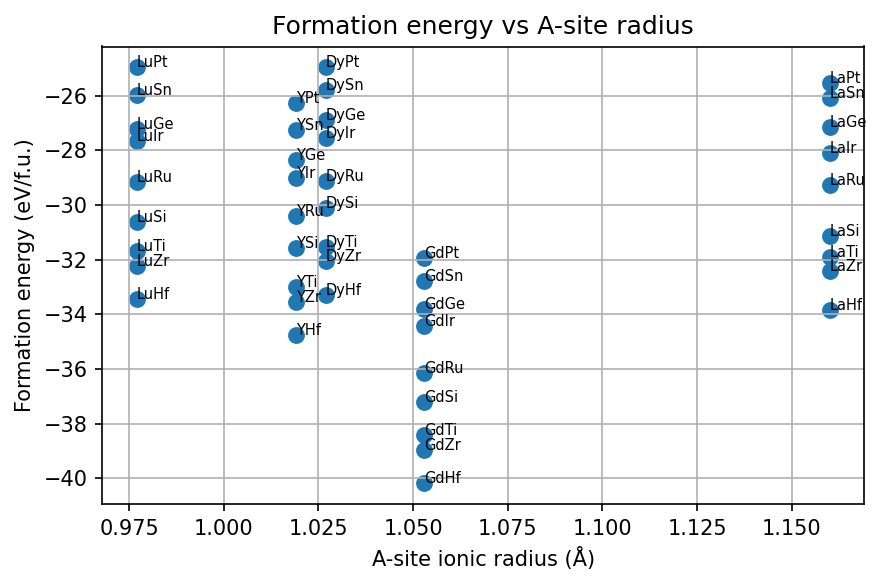

In [1]:
# ============================================================
#  ✅ Full CHGNet Pyrochlore Workflow (Two-Step Relaxation + CIFs)
# ============================================================

import os, time, json, warnings
import numpy as np, pandas as pd
from tqdm.notebook import tqdm
from pymatgen.core import Structure, Lattice
from pymatgen.io.cif import CifWriter
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.analysis.local_env import VoronoiNN
from ase.optimize import BFGS
from ase.filters import ExpCellFilter
from ase.io import write as ase_write
import matplotlib.pyplot as plt

from chgnet.model.dynamics import CHGNetCalculator  # CHGNet installed

# ------------------------
# CONFIGURATION
# ------------------------
OUT_DIR = "pyrochlore_results_fullrun18Oct25"
os.makedirs(OUT_DIR, exist_ok=True)
HAS_CHGNET = True  # since you have it installed
FORCE_CONV = 0.05


# Shannon radii (Å)
SHANNON = {
    'La':1.16, 'Ce':1.143, 'Pr':1.126, 'Nd':1.109, 'Sm':1.079, 'Eu':1.066,
    'Gd':1.053, 'Tb':1.04, 'Dy':1.027, 'Ho':1.015, 'Er':1.004, 'Tm':0.994,
    'Yb':0.985, 'Lu':0.977, 'Y':1.019, 'Sc':0.87, 'In':0.94,
    'Ti':0.745, 'Zr':0.86, 'Hf':0.85, 'Sn':0.83, 'Ge':0.73, 'Si':0.54,
    'Pt':0.765, 'Ir':0.765, 'Ru':0.76, 'Mo':0.73, 'Hg':1.02, 'Bi':1.03
}

# Dummy elemental energies (replace later if you want more precise)
FALLBACK_ELEMENTAL_REFS = {
    "Co": -6.70, "Ni": -5.45, "Ti": -7.85, "Ba": -1.87, "Mn": -8.90,
    "Fe": -4.55, "Cr": -4.10, "Cu": -4.10, "Eu": -1.95, "Al": -3.75,
    "B": -6.00, "Er": -4.90, "Gd": -4.50, "Ce": -4.85, "Dy": -5.10,
    "O": -4.93, "La": -4.60, "Pr": -4.35, "Nd": -4.30, "Pm": -4.25,
    "Sm": -4.15, "Tb": -4.10, "Ho": -4.00, "Tm": -3.90, "Yb": -6.95,
    "Lu": -4.05, "Y": -4.20, "Sb": -4.06, "Ga": -3.01, "Bi": -3.89,
    "Ge": -4.62, "Hf": -9.96, "Hg": -0.30, "In": -2.75, "Ir": -8.84,
    "Mo": -10.85, "Pt": -6.07, "Ru": -9.27, "Sc": -6.33, "Si": -5.43,
    "Sn": -4.01, "Zr": -8.55, "Pb": -3.20, "Lu": -4.05, "Dy": -5.10, "Er": -4.90,
    "Eu": -1.95 
}

# ------------------------
# RELAXATION UTILITIES
# ------------------------

def chgnet_ctor():
    """Return a new CHGNet calculator each time."""
    return CHGNetCalculator()

def get_energy_safe(atoms):
    try:
        return float(atoms.get_potential_energy())
    except Exception:
        return np.nan

def relax_two_step(struct, use_chgnet=True, atoms_steps=150, cell_steps=100,
                   atoms_fmax=0.05, cell_fmax=0.05, maxstep_atoms=0.05,
                   maxstep_cell=0.01, savepath=None):
    """Perform two-step relaxation (atoms-only → full-cell)."""
    ase_adaptor = AseAtomsAdaptor()
    ase_atoms = ase_adaptor.get_atoms(struct)
    if not use_chgnet:
        return struct.copy(), np.nan, 'none'

    calc = chgnet_ctor()
    ase_atoms.set_calculator(calc)

    # --- Step 1: atoms-only
    try:
        atoms1 = ase_adaptor.get_atoms(struct)
        atoms1.set_calculator(calc)
        dyn = BFGS(atoms1, logfile=None, maxstep=maxstep_atoms)
        dyn.run(fmax=atoms_fmax, steps=atoms_steps)
        E1 = get_energy_safe(atoms1)
        struct1 = ase_adaptor.get_structure(atoms1)
    except Exception as e:
        print("Atoms-only relaxation failed:", e)
        struct1, E1 = struct.copy(), np.nan

    # --- Step 2: full-cell relaxation
    try:
        atoms2 = ase_adaptor.get_atoms(struct1)
        atoms2.set_calculator(calc)
        cell_filter = ExpCellFilter(atoms2)
        dyn = BFGS(cell_filter, logfile=None, maxstep=maxstep_cell)
        dyn.run(fmax=cell_fmax, steps=cell_steps)
        E2 = get_energy_safe(atoms2)
        struct2 = ase_adaptor.get_structure(atoms2)
        mode = "full-cell"
        if savepath: ase_write(savepath, atoms2)
        return struct2, E2, mode
    except Exception as e:
        print("Cell+atoms relaxation failed, fallback:", e)
        if savepath: ase_write(savepath, ase_adaptor.get_atoms(struct1))
        return struct1, E1, "atoms-only"

def analyze_geometry(struct):
    """
    Compute geometric descriptors:
      - lattice parameter a
      - volume
      - mean A–O and B–O distances
      - bond valence-like mean bond distance
    """
    desc = {
        "lattice_a": struct.lattice.a,
        "volume": struct.volume,
        "A_O_mean": np.nan, "A_O_std": np.nan,
        "B_O_mean": np.nan, "B_O_std": np.nan,
        "mean_bvs": np.nan,
    }

    try:
        vnn = VoronoiNN()
        A_indices = [i for i, site in enumerate(struct) if site.specie.symbol not in ['O']]
        O_indices = [i for i, site in enumerate(struct) if site.specie.symbol == 'O']

        bonds_all = []
        bonds_AO, bonds_BO = [], []

        for i in range(len(struct)):
            for nn in vnn.get_nn_info(struct, i):
                j = nn['site_index']
                d = nn['site'].distance(struct[i])
                bonds_all.append(d)

                if struct[i].specie.symbol == 'O' and struct[j].specie.symbol != 'O':
                    # from O to metal, so classify by site type
                    el = struct[j].specie.symbol
                    if el in SHANNON.keys():  # rare earth or metal
                        if el in ['Ti','Zr','Hf','Sn','Ru','Ir','Pt','Ge','Si','Mo','Hg','Bi']:
                            bonds_BO.append(d)
                        else:
                            bonds_AO.append(d)

        desc['mean_bvs'] = np.mean(bonds_all) if bonds_all else np.nan
        if bonds_AO:
            desc['A_O_mean'] = np.mean(bonds_AO)
            desc['A_O_std'] = np.std(bonds_AO)
        if bonds_BO:
            desc['B_O_mean'] = np.mean(bonds_BO)
            desc['B_O_std'] = np.std(bonds_BO)

    except Exception as e:
        print("Geometry analysis failed:", e)

    return desc


def formation_energy(E_total, comp, refs):
    E_ref = sum(refs[el]*n for el, n in comp.items())
    return (E_total - E_ref) / sum(comp.values())

# ------------------------
# BATCH RUN FUNCTION
# ------------------------

def run_full_batch(A_list, B_list, out_dir=OUT_DIR):
    results = []
    for A in tqdm(A_list, desc="A-site loop"):
        for B in tqdm(B_list, desc=f"{A} B-site loop", leave=False):
            print(f"\n>>> Processing {A}_2{B}_2O_7 ...")
            try:
                a0 = 10.2
                struct = Structure.from_spacegroup("Fd-3m", Lattice.cubic(a0),
                            [A, B, "O"], [[0,0,0], [0.5,0.5,0.5], [0.33,0.33,0.33]])
                cif_path = os.path.join(out_dir, f"{A}_{B}_relaxed.cif")

                relaxed, E_tot, mode = relax_two_step(struct, use_chgnet=True,
                                                      savepath=cif_path)
                geom = analyze_geometry(relaxed)

                # Save supercells for visualization
                try:
                    s2 = relaxed.copy(); s2.make_supercell([2,2,2])
                    CifWriter(s2).write_file(os.path.join(out_dir, f"{A}_{B}_2x2x2.cif"))
                    s3 = relaxed.copy(); s3.make_supercell([3,3,3])
                    CifWriter(s3).write_file(os.path.join(out_dir, f"{A}_{B}_3x3x3.cif"))
                except Exception as e:
                    print("Supercell export failed:", e)

                comp = {A:2, B:2, 'O':7}
                E_form = formation_energy(E_tot, comp, FALLBACK_ELEMENTAL_REFS)

                rA = SHANNON.get(A, np.nan)
                rB = SHANNON.get(B, np.nan)

                results.append({
                    "A":A, "B":B, "E_total_eV":E_tot,
                    "formation_eV":E_form,
                    "mode": mode,
                    "rA_Ang":rA, "rB_Ang":rB,
                    **geom
                })
                print(f"Done {A}-{B}: E_tot={E_tot:.3f}, mode={mode}, a={geom['lattice_a']:.3f} Å")
            except Exception as e:
                print(f"Failed for {A}-{B}:", e)
    df = pd.DataFrame(results)
    df.to_csv(os.path.join(out_dir, "pyrochlore_summary.csv"), index=False)
    print(f"\n✅ Saved all results to {out_dir}/pyrochlore_summary.csv")
    return df

# ------------------------
# RUN + SUMMARY + PLOTS
# ------------------------

A_list = ['Y','Gd','Dy','La','Lu']
B_list = ["Ti","Ru","Pt","Sn","Ir","Mo","Pb","Ge","Si","Zr","Hf"]

df = run_full_batch(A_list, B_list, out_dir=OUT_DIR)

# Print a summary table
print("\nSummary of results:")
print(df[['A','B','mode','E_total_eV','formation_eV','lattice_a','volume']])

# Plot formation energy vs A-site radius
plt.figure(figsize=(6,4), dpi=150)
plt.scatter(df['rA_Ang'], df['formation_eV'], s=50)
for _, row in df.iterrows():
    plt.text(row['rA_Ang'], row['formation_eV'], f"{row['A']}{row['B']}", fontsize=7)
plt.xlabel("A-site ionic radius (Å)")
plt.ylabel("Formation energy (eV/f.u.)")
plt.title("Formation energy vs A-site radius")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rA_vs_Eform.png"), dpi=300)
plt.show()


A-site loop:   0%|          | 0/10 [00:00<?, ?it/s]

Bi B-site loop:   0%|          | 0/11 [00:00<?, ?it/s]


>>> Processing Bi_2Ti_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu


C:\Temp\conda_temp\ipykernel_10244\735355362.py:72: FutureWarning: Please use atoms.calc = calc
  ase_atoms.set_calculator(calc)
C:\Temp\conda_temp\ipykernel_10244\735355362.py:77: FutureWarning: Please use atoms.calc = calc
  atoms1.set_calculator(calc)
C:\Temp\conda_temp\ipykernel_10244\735355362.py:89: FutureWarning: Please use atoms.calc = calc
  atoms2.set_calculator(calc)
C:\Temp\conda_temp\ipykernel_10244\735355362.py:90: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  cell_filter = ExpCellFilter(atoms2)


✅ Bi-Ti: E_tot=-362.783, a=9.254 Å, A–O=nan, B–O=3.317

>>> Processing Bi_2Ru_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Bi-Ru: E_tot=-329.264, a=10.860 Å, A–O=nan, B–O=2.927

>>> Processing Bi_2Pt_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Bi-Pt: E_tot=-279.922, a=10.712 Å, A–O=nan, B–O=2.749

>>> Processing Bi_2Sn_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Bi-Sn: E_tot=-287.627, a=9.472 Å, A–O=nan, B–O=3.459

>>> Processing Bi_2Ir_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Bi-Ir: E_tot=-312.318, a=11.062 Å, A–O=nan, B–O=2.772

>>> Processing Bi_2Mo_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Bi-Mo: E_tot=-358.628, a=9.468 Å, A–O=nan, B–O=3.461

>>> Processing Bi_2Pb_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Bi-Pb: E_tot=-267.892, a=9.655 Å, A

...


>>> Processing Pr_2Ti_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Pr-Ti: E_tot=-412.791, a=6.750 Å, A–O=2.995, B–O=2.821

>>> Processing Pr_2Ru_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Pr-Ru: E_tot=-381.236, a=9.588 Å, A–O=2.931, B–O=2.944

>>> Processing Pr_2Pt_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Pr-Pt: E_tot=-331.140, a=6.785 Å, A–O=2.581, B–O=3.051

>>> Processing Pr_2Sn_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Pr-Sn: E_tot=-333.656, a=9.685 Å, A–O=3.590, B–O=3.484

>>> Processing Pr_2Ir_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Pr-Ir: E_tot=-365.077, a=6.556 Å, A–O=2.556, B–O=2.805

>>> Processing Pr_2Mo_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Pr-Mo: E_tot=-412.072, a=10.755 Å, A–O=2.621, B–O=2.827

>>> Processing Pr_2Pb_2O_7

Nd B-site loop:   0%|          | 0/11 [00:00<?, ?it/s]


>>> Processing Nd_2Ti_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Nd-Ti: E_tot=-405.519, a=9.397 Å, A–O=3.515, B–O=3.353

>>> Processing Nd_2Ru_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Nd-Ru: E_tot=-384.016, a=9.946 Å, A–O=2.514, B–O=2.923

>>> Processing Nd_2Pt_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Nd-Pt: E_tot=-328.180, a=7.101 Å, A–O=2.942, B–O=2.865

>>> Processing Nd_2Sn_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Nd-Sn: E_tot=-338.599, a=9.591 Å, A–O=3.078, B–O=3.030

>>> Processing Nd_2Ir_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Nd-Ir: E_tot=-364.784, a=10.548 Å, A–O=2.749, B–O=2.605

>>> Processing Nd_2Mo_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Nd-Mo: E_tot=-412.556, a=10.549 Å, A–O=2.576, B–O=3.065

>>> Processing Nd_2Pb_2O_

Sm B-site loop:   0%|          | 0/11 [00:00<?, ?it/s]


>>> Processing Sm_2Ti_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Sm-Ti: E_tot=-406.210, a=9.316 Å, A–O=3.478, B–O=3.331

>>> Processing Sm_2Ru_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Sm-Ru: E_tot=-381.271, a=6.658 Å, A–O=2.844, B–O=2.851

>>> Processing Sm_2Pt_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Sm-Pt: E_tot=-331.734, a=10.671 Å, A–O=2.582, B–O=2.955

>>> Processing Sm_2Sn_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Sm-Sn: E_tot=-339.233, a=11.159 Å, A–O=2.893, B–O=3.201

>>> Processing Sm_2Ir_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Sm-Ir: E_tot=-365.504, a=10.434 Å, A–O=2.579, B–O=2.757

>>> Processing Sm_2Mo_2O_7 ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Sm-Mo: E_tot=-412.476, a=10.377 Å, A–O=2.551, B–O=2.611

>>> Processing Sm_2Pb_2

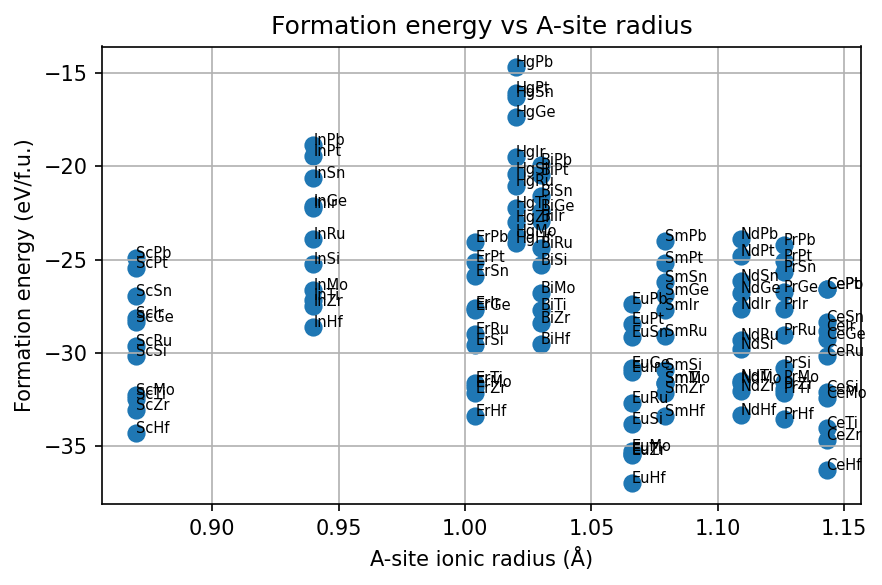

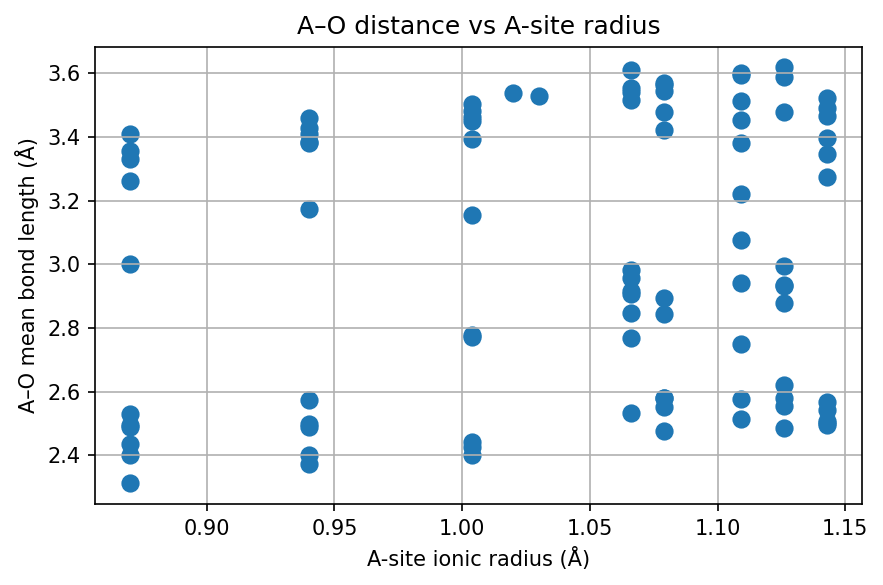

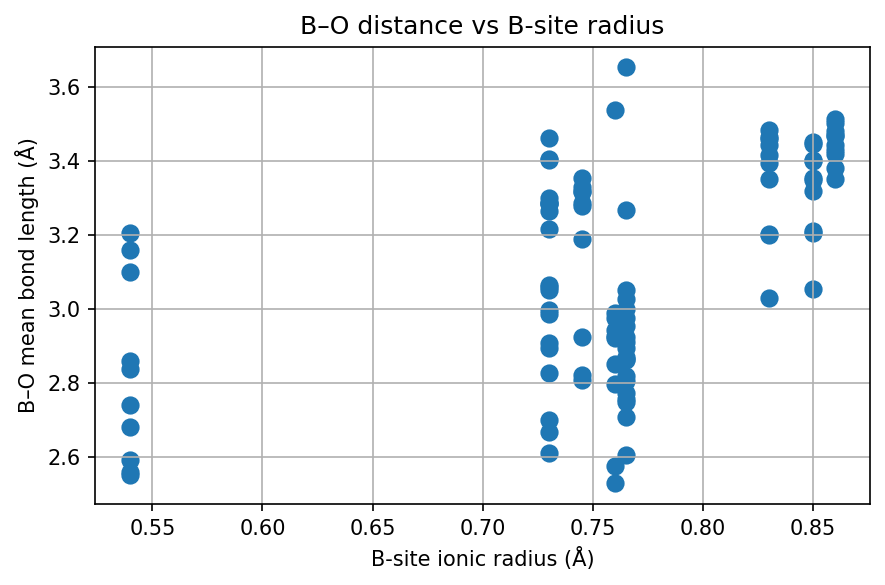


✅ All plots saved in: pyrochlore_results_fullrun18Oct25-2


In [5]:
# ============================================================
# ✅ Full CHGNet Pyrochlore Workflow (with A–O and B–O analysis)
# ============================================================

import os, time, json, warnings
import numpy as np, pandas as pd
from tqdm.notebook import tqdm
from pymatgen.core import Structure, Lattice
from pymatgen.io.cif import CifWriter
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.analysis.local_env import VoronoiNN
from ase.optimize import BFGS
from ase.filters import ExpCellFilter
from ase.io import write as ase_write
import matplotlib.pyplot as plt

from chgnet.model.dynamics import CHGNetCalculator  # CHGNet installed

# ------------------------
# CONFIGURATION
# ------------------------
OUT_DIR = "pyrochlore_results_fullrun18Oct25-2"
os.makedirs(OUT_DIR, exist_ok=True)
HAS_CHGNET = True
FORCE_CONV = 0.05

# Shannon radii (Å)
SHANNON = {
    'La':1.16, 'Ce':1.143, 'Pr':1.126, 'Nd':1.109, 'Sm':1.079, 'Eu':1.066,
    'Gd':1.053, 'Tb':1.04, 'Dy':1.027, 'Ho':1.015, 'Er':1.004, 'Tm':0.994,
    'Yb':0.985, 'Lu':0.977, 'Y':1.019, 'Sc':0.87, 'In':0.94,
    'Ti':0.745, 'Zr':0.86, 'Hf':0.85, 'Sn':0.83, 'Ge':0.73, 'Si':0.54,
    'Pt':0.765, 'Ir':0.765, 'Ru':0.76, 'Mo':0.73, 'Hg':1.02, 'Bi':1.03
}

# Reference elemental energies (eV/atom)
ELEMENTAL_REF_ENERGIES = {
    "Co": -6.70, "Ni": -5.45, "Ti": -7.85, "Ba": -1.87, "Mn": -8.90,
    "Fe": -4.55, "Cr": -4.10, "Cu": -4.10, "Eu": -1.95, "Al": -3.75,
    "B": -6.00, "Er": -4.90, "Gd": -4.50, "Ce": -4.85, "Dy": -5.10,
    "O": -4.93, "La": -4.60, "Pr": -4.35, "Nd": -4.30, "Pm": -4.25,
    "Sm": -4.15, "Tb": -4.10, "Ho": -4.00, "Tm": -3.90, "Yb": -6.95,
    "Lu": -4.05, "Y": -4.20, "Sb": -4.06, "Ga": -3.01, "Bi": -3.89,
    "Ge": -4.62, "Hf": -9.96, "Hg": -0.30, "In": -2.75, "Ir": -8.84,
    "Mo": -10.85, "Pt": -6.07, "Ru": -9.27, "Sc": -6.33, "Si": -5.43,
    "Sn": -4.01, "Zr": -8.55, "Pb": -3.20
}

# ------------------------
# RELAXATION UTILITIES
# ------------------------

def chgnet_ctor():
    return CHGNetCalculator()

def get_energy_safe(atoms):
    try:
        return float(atoms.get_potential_energy())
    except Exception:
        return np.nan

def relax_two_step(struct, use_chgnet=True, atoms_steps=150, cell_steps=100,
                   atoms_fmax=0.05, cell_fmax=0.05, maxstep_atoms=0.05,
                   maxstep_cell=0.01, savepath=None):
    """Perform two-step relaxation (atoms-only → full-cell)."""
    ase_adaptor = AseAtomsAdaptor()
    ase_atoms = ase_adaptor.get_atoms(struct)
    if not use_chgnet:
        return struct.copy(), np.nan, 'none'

    calc = chgnet_ctor()
    ase_atoms.set_calculator(calc)

    # Step 1: atoms-only
    try:
        atoms1 = ase_adaptor.get_atoms(struct)
        atoms1.set_calculator(calc)
        dyn = BFGS(atoms1, logfile=None, maxstep=maxstep_atoms)
        dyn.run(fmax=atoms_fmax, steps=atoms_steps)
        E1 = get_energy_safe(atoms1)
        struct1 = ase_adaptor.get_structure(atoms1)
    except Exception as e:
        print("Atoms-only relaxation failed:", e)
        struct1, E1 = struct.copy(), np.nan

    # Step 2: full-cell relaxation
    try:
        atoms2 = ase_adaptor.get_atoms(struct1)
        atoms2.set_calculator(calc)
        cell_filter = ExpCellFilter(atoms2)
        dyn = BFGS(cell_filter, logfile=None, maxstep=maxstep_cell)
        dyn.run(fmax=cell_fmax, steps=cell_steps)
        E2 = get_energy_safe(atoms2)
        struct2 = ase_adaptor.get_structure(atoms2)
        if savepath: ase_write(savepath, atoms2)
        return struct2, E2, "full-cell"
    except Exception as e:
        print("Cell+atoms relaxation failed:", e)
        if savepath: ase_write(savepath, ase_adaptor.get_atoms(struct1))
        return struct1, E1, "atoms-only"

# ------------------------
# GEOMETRY + ANALYSIS
# ------------------------

def analyze_geometry(struct):
    """
    Compute:
      - lattice constant
      - volume
      - mean A–O and B–O bond lengths (+std)
    """
    desc = {
        "lattice_a": struct.lattice.a,
        "volume": struct.volume,
        "A_O_mean": np.nan, "A_O_std": np.nan,
        "B_O_mean": np.nan, "B_O_std": np.nan,
    }

    try:
        vnn = VoronoiNN()
        bonds_AO, bonds_BO = [], []

        for i, site in enumerate(struct):
            el = site.specie.symbol
            if el == "O":
                continue
            for nn in vnn.get_nn_info(struct, i):
                if nn['site'].specie.symbol == "O":
                    dist = nn['site'].distance(site)
                    if el in ['Ti','Zr','Hf','Sn','Ru','Ir','Pt','Ge','Si','Mo','Hg','Bi']:
                        bonds_BO.append(dist)
                    else:
                        bonds_AO.append(dist)

        if bonds_AO:
            desc["A_O_mean"] = np.mean(bonds_AO)
            desc["A_O_std"] = np.std(bonds_AO)
        if bonds_BO:
            desc["B_O_mean"] = np.mean(bonds_BO)
            desc["B_O_std"] = np.std(bonds_BO)

    except Exception as e:
        print("Geometry analysis failed:", e)

    return desc

def formation_energy(E_total, comp, refs):
    E_ref = sum(refs[el] * n for el, n in comp.items())
    return (E_total - E_ref) / sum(comp.values())

# ------------------------
# BATCH EXECUTION
# ------------------------

def run_full_batch(A_list, B_list, out_dir=OUT_DIR):
    results = []
    for A in tqdm(A_list, desc="A-site loop"):
        for B in tqdm(B_list, desc=f"{A} B-site loop", leave=False):
            print(f"\n>>> Processing {A}_2{B}_2O_7 ...")
            try:
                struct = Structure.from_spacegroup(
                    "Fd-3m", Lattice.cubic(10.2),
                    [A, B, "O"], [[0,0,0], [0.5,0.5,0.5], [0.33,0.33,0.33]]
                )
                cif_path = os.path.join(out_dir, f"{A}_{B}_relaxed.cif")

                relaxed, E_tot, mode = relax_two_step(struct, use_chgnet=True, savepath=cif_path)
                geom = analyze_geometry(relaxed)

                # Save supercells for visualization
                try:
                    for n in [2,3]:
                        s = relaxed.copy()
                        s.make_supercell([n,n,n])
                        CifWriter(s).write_file(os.path.join(out_dir, f"{A}_{B}_{n}x{n}x{n}.cif"))
                except Exception as e:
                    print("Supercell export failed:", e)

                comp = {A:2, B:2, 'O':7}
                E_form = formation_energy(E_tot, comp, ELEMENTAL_REF_ENERGIES)

                rA = SHANNON.get(A, np.nan)
                rB = SHANNON.get(B, np.nan)

                results.append({
                    "A":A, "B":B, "E_total_eV":E_tot, "formation_eV":E_form,
                    "rA_Ang":rA, "rB_Ang":rB, **geom
                })

                print(f"✅ {A}-{B}: E_tot={E_tot:.3f}, a={geom['lattice_a']:.3f} Å, "
                      f"A–O={geom['A_O_mean']:.3f}, B–O={geom['B_O_mean']:.3f}")

            except Exception as e:
                print(f"❌ Failed for {A}-{B}:", e)

    df = pd.DataFrame(results)
    df.to_csv(os.path.join(out_dir, "pyrochlore_summary.csv"), index=False)
    print(f"\n✅ Results saved to {out_dir}/pyrochlore_summary.csv")
    return df

# ------------------------
# RUN + PLOTS
# ------------------------
A_list = ["Bi","Er","Eu","Hg","In","Sc","Ce","Pr","Nd","Sm"]
B_list = ["Ti","Ru","Pt","Sn","Ir","Mo","Pb","Ge","Si","Zr","Hf"]

df = run_full_batch(A_list, B_list, out_dir=OUT_DIR)

# ---- PLOTS ----
plt.figure(figsize=(6,4), dpi=150)
plt.scatter(df['rA_Ang'], df['formation_eV'], s=60)
for _, row in df.iterrows():
    plt.text(row['rA_Ang'], row['formation_eV'], f"{row['A']}{row['B']}", fontsize=7)
plt.xlabel("A-site ionic radius (Å)")
plt.ylabel("Formation energy (eV/f.u.)")
plt.title("Formation energy vs A-site radius")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rA_vs_Eform.png"), dpi=300)
plt.show()

plt.figure(figsize=(6,4), dpi=150)
plt.scatter(df['rA_Ang'], df['A_O_mean'], s=60)
plt.xlabel("A-site ionic radius (Å)")
plt.ylabel("A–O mean bond length (Å)")
plt.title("A–O distance vs A-site radius")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rA_vs_AO.png"), dpi=300)
plt.show()

plt.figure(figsize=(6,4), dpi=150)
plt.scatter(df['rB_Ang'], df['B_O_mean'], s=60)
plt.xlabel("B-site ionic radius (Å)")
plt.ylabel("B–O mean bond length (Å)")
plt.title("B–O distance vs B-site radius")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rB_vs_BO.png"), dpi=300)
plt.show()

print("\n✅ All plots saved in:", OUT_DIR)


In [ ]:
 With fixed unitcell

A-site loop:   0%|          | 0/15 [00:00<?, ?it/s]

Ga B-site loop:   0%|          | 0/11 [00:00<?, ?it/s]


>>> Processing Ga_2Ti_2O_7 with a₀ = 10.090 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu


C:\Temp\conda_temp\ipykernel_10244\1066380095.py:67: FutureWarning: Please use atoms.calc = calc
  atoms.set_calculator(calc)


✅ Ga-Ti: a₀=10.090 Å, E=-356.428 eV, A–O=3.411, B–O=3.083

>>> Processing Ga_2Ru_2O_7 with a₀ = 10.177 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Ga-Ru: a₀=10.177 Å, E=-311.690 eV, A–O=3.896, B–O=3.567

>>> Processing Ga_2Pt_2O_7 with a₀ = 10.206 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Ga-Pt: a₀=10.206 Å, E=-228.892 eV, A–O=3.679, B–O=3.776

>>> Processing Ga_2Sn_2O_7 with a₀ = 10.582 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Ga-Sn: a₀=10.582 Å, E=-241.834 eV, A–O=3.726, B–O=4.026

>>> Processing Ga_2Ir_2O_7 with a₀ = 10.206 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Ga-Ir: a₀=10.206 Å, E=-292.469 eV, A–O=3.897, B–O=3.584

>>> Processin

...


>>> Processing Pr_2Ti_2O_7 with a₀ = 10.819 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Pr-Ti: a₀=10.819 Å, E=-369.299 eV, A–O=4.117, B–O=3.809

>>> Processing Pr_2Ru_2O_7 with a₀ = 10.905 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Pr-Ru: a₀=10.905 Å, E=-343.084 eV, A–O=4.201, B–O=3.804

>>> Processing Pr_2Pt_2O_7 with a₀ = 10.934 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Pr-Pt: a₀=10.934 Å, E=-289.596 eV, A–O=4.160, B–O=3.850

>>> Processing Pr_2Sn_2O_7 with a₀ = 11.310 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Pr-Sn: a₀=11.310 Å, E=-292.145 eV, A–O=4.249, B–O=4.022

>>> Processing Pr_2Ir_2O_7 with a₀ = 10.934 Å ...
CHGNet v0.3.0 initial

Nd B-site loop:   0%|          | 0/11 [00:00<?, ?it/s]


>>> Processing Nd_2Ti_2O_7 with a₀ = 10.720 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Nd-Ti: a₀=10.720 Å, E=-371.691 eV, A–O=4.071, B–O=3.780

>>> Processing Nd_2Ru_2O_7 with a₀ = 10.807 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Nd-Ru: a₀=10.807 Å, E=-343.776 eV, A–O=4.155, B–O=3.776

>>> Processing Nd_2Pt_2O_7 with a₀ = 10.836 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Nd-Pt: a₀=10.836 Å, E=-291.034 eV, A–O=4.106, B–O=3.827

>>> Processing Nd_2Sn_2O_7 with a₀ = 11.212 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Nd-Sn: a₀=11.212 Å, E=-293.792 eV, A–O=4.204, B–O=3.994

>>> Processing Nd_2Ir_2O_7 with a₀ = 10.836 Å ...
CHGNet v0.3.0 initial

Sm B-site loop:   0%|          | 0/11 [00:00<?, ?it/s]


>>> Processing Sm_2Ti_2O_7 with a₀ = 10.547 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Sm-Ti: a₀=10.547 Å, E=-375.675 eV, A–O=3.993, B–O=3.728

>>> Processing Sm_2Ru_2O_7 with a₀ = 10.634 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Sm-Ru: a₀=10.634 Å, E=-346.052 eV, A–O=4.061, B–O=3.733

>>> Processing Sm_2Pt_2O_7 with a₀ = 10.663 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Sm-Pt: a₀=10.663 Å, E=-293.994 eV, A–O=4.022, B–O=3.780

>>> Processing Sm_2Sn_2O_7 with a₀ = 11.038 Å ...
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
✅ Sm-Sn: a₀=11.038 Å, E=-297.217 eV, A–O=4.116, B–O=3.951

>>> Processing Sm_2Ir_2O_7 with a₀ = 10.663 Å ...
CHGNet v0.3.0 initial

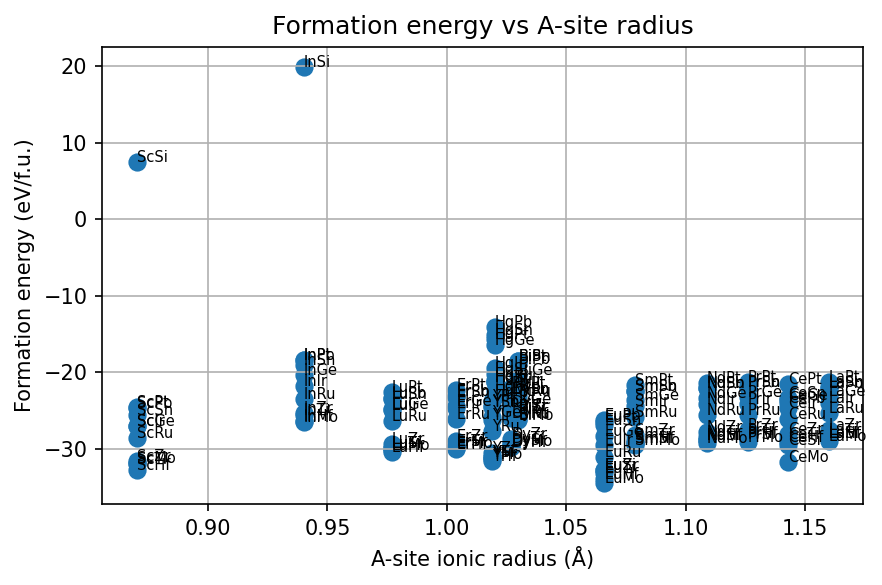

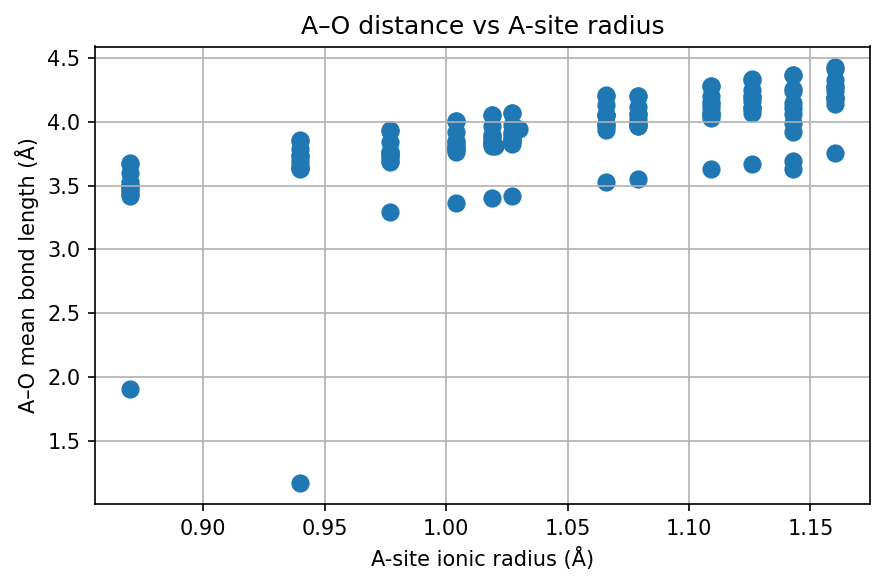

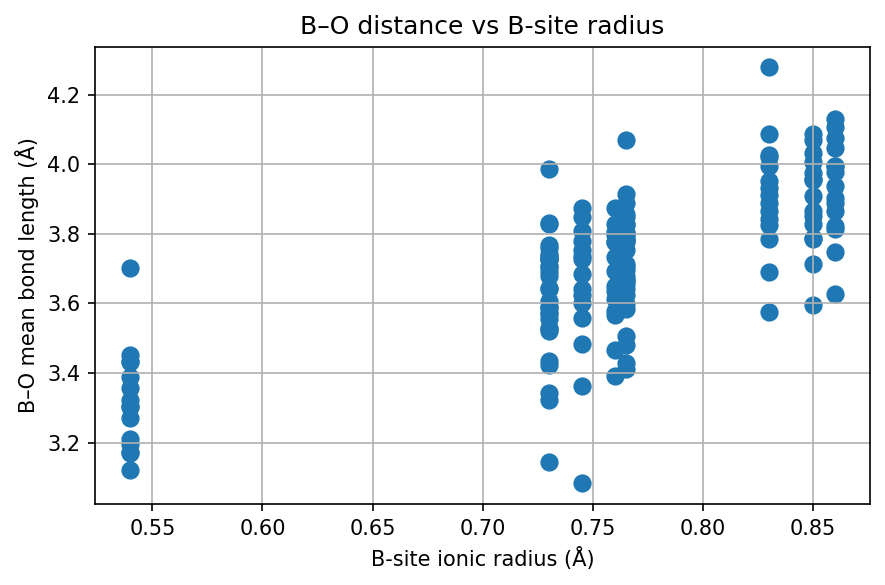


✅ All plots saved in: pyrochlore_results_fixed_scaled_18Oct25-FixedUnitcell


In [6]:
# ============================================================
# ✅ CHGNet Pyrochlore Workflow (Fixed-Cell, Radius-Scaled Lattice)
# ============================================================

import os, warnings
import numpy as np, pandas as pd
from tqdm.notebook import tqdm
from pymatgen.core import Structure, Lattice
from pymatgen.io.cif import CifWriter
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.analysis.local_env import VoronoiNN, MinimumDistanceNN
from ase.optimize import BFGS
from ase.io import write as ase_write
import matplotlib.pyplot as plt
from chgnet.model.dynamics import CHGNetCalculator  # CHGNet installed

# ------------------------
# CONFIGURATION
# ------------------------
OUT_DIR = "pyrochlore_results_fixed_scaled_18Oct25-FixedUnitcell"
os.makedirs(OUT_DIR, exist_ok=True)
FORCE_CONV = 0.05

# Shannon radii (Å)
SHANNON = {
    'La':1.16, 'Ce':1.143, 'Pr':1.126, 'Nd':1.109, 'Sm':1.079, 'Eu':1.066,
    'Gd':1.053, 'Tb':1.04, 'Dy':1.027, 'Ho':1.015, 'Er':1.004, 'Tm':0.994,
    'Yb':0.985, 'Lu':0.977, 'Y':1.019, 'Sc':0.87, 'In':0.94,
    'Ti':0.745, 'Zr':0.86, 'Hf':0.85, 'Sn':0.83, 'Ge':0.73, 'Si':0.54,
    'Pt':0.765, 'Ir':0.765, 'Ru':0.76, 'Mo':0.73, 'Hg':1.02, 'Bi':1.03
}

# Reference elemental energies (eV/atom)
ELEMENTAL_REF_ENERGIES = {
    "Co": -6.70, "Ni": -5.45, "Ti": -7.85, "Ba": -1.87, "Mn": -8.90,
    "Fe": -4.55, "Cr": -4.10, "Cu": -4.10, "Eu": -1.95, "Al": -3.75,
    "B": -6.00, "Er": -4.90, "Gd": -4.50, "Ce": -4.85, "Dy": -5.10,
    "O": -4.93, "La": -4.60, "Pr": -4.35, "Nd": -4.30, "Pm": -4.25,
    "Sm": -4.15, "Tb": -4.10, "Ho": -4.00, "Tm": -3.90, "Yb": -6.95,
    "Lu": -4.05, "Y": -4.20, "Sb": -4.06, "Ga": -3.01, "Bi": -3.89,
    "Ge": -4.62, "Hf": -9.96, "Hg": -0.30, "In": -2.75, "Ir": -8.84,
    "Mo": -10.85, "Pt": -6.07, "Ru": -9.27, "Sc": -6.33, "Si": -5.43,
    "Sn": -4.01, "Zr": -8.55, "Pb": -3.20
}

# ------------------------
# RELAXATION (Fixed Cell)
# ------------------------
def chgnet_ctor():
    """Create CHGNet calculator, preferring GPU if available."""
    try:
        return CHGNetCalculator(use_device="cuda")
    except Exception:
        return CHGNetCalculator()

def get_energy_safe(atoms):
    try:
        return float(atoms.get_potential_energy())
    except Exception:
        return np.nan

def relax_fixed_cell(struct, atoms_steps=200, fmax=0.05, maxstep=0.05, savepath=None):
    """Relax atomic positions only, keeping cell fixed."""
    ase_adaptor = AseAtomsAdaptor()
    atoms = ase_adaptor.get_atoms(struct)
    calc = chgnet_ctor()
    atoms.set_calculator(calc)

    try:
        dyn = BFGS(atoms, logfile=None, maxstep=maxstep)
        dyn.run(fmax=fmax, steps=atoms_steps)
        E = get_energy_safe(atoms)
        struct_relaxed = ase_adaptor.get_structure(atoms)
        if savepath:
            CifWriter(struct_relaxed).write_file(savepath)
        return struct_relaxed, E, "fixed-cell"
    except Exception as e:
        print("Relaxation failed:", e)
        return struct.copy(), np.nan, "failed"

# ------------------------
# GEOMETRY + ANALYSIS
# ------------------------
def analyze_geometry(struct):
    """Compute lattice constant, volume, mean A–O and B–O bond lengths."""
    desc = {
        "lattice_a": struct.lattice.a,
        "volume": struct.volume,
        "A_O_mean": np.nan, "A_O_std": np.nan,
        "B_O_mean": np.nan, "B_O_std": np.nan,
    }

    try:
        vnn = VoronoiNN()
        bonds_AO, bonds_BO = [], []

        for i, site in enumerate(struct):
            el = site.specie.symbol
            if el == "O":
                continue
            try:
                nns = vnn.get_nn_info(struct, i)
            except Exception:
                vnn = MinimumDistanceNN(cutoff=3.5)
                nns = vnn.get_nn_info(struct, i)

            for nn in nns:
                if nn['site'].specie.symbol == "O":
                    dist = nn['site'].distance(site)
                    if el in ['Ti','Zr','Hf','Sn','Ru','Ir','Pt','Ge','Si','Mo','Hg','Bi']:
                        bonds_BO.append(dist)
                    else:
                        bonds_AO.append(dist)

        if bonds_AO:
            desc["A_O_mean"] = np.mean(bonds_AO)
            desc["A_O_std"] = np.std(bonds_AO)
        if bonds_BO:
            desc["B_O_mean"] = np.mean(bonds_BO)
            desc["B_O_std"] = np.std(bonds_BO)
    except Exception as e:
        print("Geometry analysis failed:", e)

    return desc

# ------------------------
# FORMATION ENERGY
# ------------------------
def formation_energy(E_total, comp, refs):
    try:
        E_ref = sum(refs.get(el, 0) * n for el, n in comp.items())
        return (E_total - E_ref) / sum(comp.values())
    except Exception:
        return np.nan

# ------------------------
# ESTIMATE LATTICE CONSTANT (radius scaling)
# ------------------------
def estimate_lattice_constant(A, B, base_a=10.2):
    """Estimate lattice constant based on Shannon radii of A and B."""
    rA = SHANNON.get(A, 1.0)
    rB = SHANNON.get(B, 0.8)
    # Empirical linear scaling around Y₂Ti₂O₇ reference
    a = base_a * (0.5 * (rA + rB)) / (0.5 * (SHANNON['Y'] + SHANNON['Ti']))
    return round(a, 3)

# ------------------------
# MAIN EXECUTION
# ------------------------
def run_full_batch(A_list, B_list, out_dir=OUT_DIR):
    results = []
    for A in tqdm(A_list, desc="A-site loop"):
        for B in tqdm(B_list, desc=f"{A} B-site loop", leave=False):
            try:
                a0 = estimate_lattice_constant(A, B)
                print(f"\n>>> Processing {A}_2{B}_2O_7 with a₀ = {a0:.3f} Å ...")

                struct = Structure.from_spacegroup(
                    "Fd-3m", Lattice.cubic(a0),
                    [A, B, "O"], [[0,0,0], [0.5,0.5,0.5], [0.33,0.33,0.33]]
                )
                cif_path = os.path.join(out_dir, f"{A}_{B}_relaxed.cif")

                relaxed, E_tot, mode = relax_fixed_cell(struct, savepath=cif_path)
                geom = analyze_geometry(relaxed)

                # Save supercells for VESTA
                for n in [2,3]:
                    try:
                        s = relaxed.copy()
                        s.make_supercell([n,n,n])
                        CifWriter(s).write_file(os.path.join(out_dir, f"{A}_{B}_{n}x{n}x{n}.cif"))
                    except Exception as e:
                        print(f"Supercell {n}x{n}x{n} export failed:", e)

                comp = {A:2, B:2, 'O':7}
                E_form = formation_energy(E_tot, comp, ELEMENTAL_REF_ENERGIES)
                rA = SHANNON.get(A, np.nan)
                rB = SHANNON.get(B, np.nan)

                results.append({
                    "A":A, "B":B, "a_init_Ang":a0,
                    "E_total_eV":E_tot, "formation_eV":E_form,
                    "rA_Ang":rA, "rB_Ang":rB, **geom
                })

                print(f"✅ {A}-{B}: a₀={a0:.3f} Å, E={E_tot:.3f} eV, "
                      f"A–O={geom['A_O_mean']:.3f}, B–O={geom['B_O_mean']:.3f}")

            except Exception as e:
                print(f"❌ Failed for {A}-{B}:", e)

    df = pd.DataFrame(results)
    df.to_csv(os.path.join(out_dir, "pyrochlore_summary.csv"), index=False)
    print(f"\n✅ Results saved to {out_dir}/pyrochlore_summary.csv")
    return df

# ------------------------
# RUN + PLOTS
# ------------------------
A_list = ["Ga","Dy","La","Lu","Y","Bi","Er","Eu","Hg","In","Sc","Ce","Pr","Nd","Sm"]
B_list = ["Ti","Ru","Pt","Sn","Ir","Mo","Pb","Ge","Si","Zr","Hf"]

df = run_full_batch(A_list, B_list, out_dir=OUT_DIR)

# ---- PLOTS ----
plt.figure(figsize=(6,4), dpi=150)
plt.scatter(df['rA_Ang'], df['formation_eV'], s=60)
for _, row in df.iterrows():
    plt.text(row['rA_Ang'], row['formation_eV'], f"{row['A']}{row['B']}", fontsize=7)
plt.xlabel("A-site ionic radius (Å)")
plt.ylabel("Formation energy (eV/f.u.)")
plt.title("Formation energy vs A-site radius")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rA_vs_Eform.png"), dpi=300)
plt.show()

plt.figure(figsize=(6,4), dpi=150)
plt.scatter(df['rA_Ang'], df['A_O_mean'], s=60)
plt.xlabel("A-site ionic radius (Å)")
plt.ylabel("A–O mean bond length (Å)")
plt.title("A–O distance vs A-site radius")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rA_vs_AO.png"), dpi=300)
plt.show()

plt.figure(figsize=(6,4), dpi=150)
plt.scatter(df['rB_Ang'], df['B_O_mean'], s=60)
plt.xlabel("B-site ionic radius (Å)")
plt.ylabel("B–O mean bond length (Å)")
plt.title("B–O distance vs B-site radius")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rB_vs_BO.png"), dpi=300)
plt.show()

print("\n✅ All plots saved in:", OUT_DIR)
